# Attention Task Validation Experiment Analysis

## Section 1 - Load All Data (Single & Multiple / Lab & Game)

In [84]:
import os, glob, re, ast
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pingouin as pg
from IPython.display import display

In [85]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12})

In [86]:
BASE_DIR   = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR   = os.path.join(BASE_DIR, "data_brsm")

SINGLE_LAB   = os.path.join(DATA_DIR, "single",   "lab")
SINGLE_PHONE = os.path.join(DATA_DIR, "single",   "phone")
MULTI_LAB    = os.path.join(DATA_DIR, "multiple",  "lab")
MULTI_PHONE  = os.path.join(DATA_DIR, "multiple",  "phone")

def _pid(path):
    m = re.match(r"^(\d+)", os.path.basename(path))
    return m.group(1) if m else os.path.basename(path)

def load_folder(folder):
    files = sorted(glob.glob(os.path.join(folder, "*.csv")))
    return {_pid(f): pd.read_csv(f) for f in files}

single_lab_raw   = load_folder(SINGLE_LAB)
single_phone_raw = load_folder(SINGLE_PHONE)
multi_lab_raw    = load_folder(MULTI_LAB)
multi_phone_raw  = load_folder(MULTI_PHONE)

print(f"Single - Lab: {sorted(single_lab_raw.keys(), key=int)}")
print(f"Single - Game: {sorted(single_phone_raw.keys(), key=int)}")
print(f"Multi - Lab: {sorted(multi_lab_raw.keys(), key=int)}")
print(f"Multi - Game: {sorted(multi_phone_raw.keys(), key=int)}")

Single - Lab: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21']
Single - Game: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21']
Multi - Lab: ['22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37']
Multi - Game: ['22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37']


## Section 2 - Feature Extraction & Per-Participant Summary

In [87]:
import ast as _ast

def _parse(v):
    try: return _ast.literal_eval(str(v).strip())
    except: return []

print("=" * 70)
print("  DIAGNOSTIC - Lab accuracy columns")
print("=" * 70)

print("\n--- SINGLE TARGET LAB ---")
print("Relevant columns in a sample file:")
sample_single = next(iter(single_lab_raw.values()))
trial_rows_s  = sample_single.dropna(subset=["trial.started"])
print("  Columns present:", [c for c in ["target_col", "mouse.clicked_name", "feedback.stopped", "fb.stopped", "notes"] if c in sample_single.columns])

clicked_unique_s = set()
for _, row in trial_rows_s.iterrows():
    for name in _parse(row.get("mouse.clicked_name", "[]")):
        clicked_unique_s.add(name)
print(f"  All unique clicked object names across all single-lab trials: {sorted(clicked_unique_s)}")
print(f"  Number of trial rows: {len(trial_rows_s)}")
print(f"  'fb.stopped' column exists: {'fb.stopped' in sample_single.columns}")

if "feedback.stopped" in sample_single.columns:
    fb_populated = trial_rows_s["feedback.stopped"].notna().sum()
    print(f"  'feedback.stopped' populated in {fb_populated}/{len(trial_rows_s)} trial rows")

print("\n--- MULTIPLE TARGET LAB ---")
sample_multi = next(iter(multi_lab_raw.values()))
trial_rows_m = sample_multi.dropna(subset=["trial.started"])
print("  Columns present:", [c for c in ["target_col", "mouse.clicked_name", "feedback.stopped", "fb.stopped", "notes"] if c in sample_multi.columns])

clicked_unique_m = set()
for _, row in trial_rows_m.iterrows():
    for name in _parse(row.get("mouse.clicked_name", "[]")):
        clicked_unique_m.add(name)
print(f"  All unique clicked object names: {sorted(clicked_unique_m)}")

click_counts = trial_rows_m["mouse.clicked_name"].apply(lambda v: len(_parse(v)))
print(f"  Clicks per trial — min: {click_counts.min()}, max: {click_counts.max()}, "
      f"mean: {click_counts.mean():.1f}")

if "fb.stopped" in sample_multi.columns:
    fb_m = trial_rows_m["fb.stopped"].notna().sum()
    print(f"  'fb.stopped' populated in {fb_m}/{len(trial_rows_m)} trial rows")
    cross = trial_rows_m.groupby("target_col")["fb.stopped"].apply(lambda x: x.notna().sum())
    print(f"  'fb.stopped' by target_col:\n{cross.to_string()}")

print("\n  POOLED across ALL multi-lab participants:")
total_trials, fb_trials, non_target_clicks = 0, 0, 0
for pid, df in multi_lab_raw.items():
    tr = df.dropna(subset=["trial.started"])
    total_trials += len(tr)
    if "fb.stopped" in df.columns:
        fb_trials += tr["fb.stopped"].notna().sum()
    for _, row in tr.iterrows():
        names = _parse(row.get("mouse.clicked_name", "[]"))
        non_target_clicks += sum(1 for n in names if "target" not in str(n).lower())
print(f"  Total trial rows: {total_trials}")
print(f"  Trials with fb.stopped populated: {fb_trials}  ({100*fb_trials/total_trials:.1f}%)")
print(f"  Clicks on non-target named objects: {non_target_clicks}")
print(f"\n  Conclusion: 'fb.stopped' is populated on {100*fb_trials/total_trials:.1f}% of trials.")

  DIAGNOSTIC - Lab accuracy columns

--- SINGLE TARGET LAB ---
Relevant columns in a sample file:
  Columns present: ['target_col', 'mouse.clicked_name', 'feedback.stopped', 'fb.stopped', 'notes']
  All unique clicked object names across all single-lab trials: ['target']
  Number of trial rows: 15
  'fb.stopped' column exists: True
  'feedback.stopped' populated in 15/15 trial rows

--- MULTIPLE TARGET LAB ---
  Columns present: ['target_col', 'mouse.clicked_name', 'feedback.stopped', 'fb.stopped', 'notes']
  All unique clicked object names: ['target_0', 'target_1', 'target_2', 'target_3', 'target_4']
  Clicks per trial — min: 5, max: 5, mean: 5.0
  'fb.stopped' populated in 5/15 trial rows
  'fb.stopped' by target_col:
target_col
red      2
white    3

  POOLED across ALL multi-lab participants:
  Total trial rows: 240
  Trials with fb.stopped populated: 142  (59.2%)
  Clicks on non-target named objects: 0

  Conclusion: 'fb.stopped' is populated on 59.2% of trials.


In [88]:
def parse_list_col(val):
    if pd.isna(val):
        return []
    try:
        return ast.literal_eval(str(val).strip())
    except Exception:
        return []


def lab_features(raw_dict, condition="single"):
    records = []
    for pid, df in raw_dict.items():
        trials = df.dropna(subset=["trial.started"])
        rts, accs = [], []
        for _, row in trials.iterrows():
            times = parse_list_col(row.get("mouse.time", np.nan))
            if times:
                rts.append(float(times[0]) * 1000)
                # Use PsychoPy feedback stop marker for both Single and Multiple lab
                # NaN => no error feedback fired (correct), not-NaN => error feedback fired
                fb_val = row.get("fb.stopped", np.nan)
                accs.append(0.0 if pd.notna(fb_val) else 1.0)
        if rts:
            records.append(dict(pid=int(pid), mean_RT=np.mean(rts), sd_RT=np.std(rts, ddof=1), mean_Acc=np.mean(accs) * 100, n_trials=len(rts)))
    return pd.DataFrame(records).sort_values("pid").reset_index(drop=True)


def game_features(raw_dict):
    records = []
    for pid, df in raw_dict.items():
        valid = df.dropna(subset=["InitialResponseTime(ms)", "SuccessRate(%)"])
        if len(valid):
            records.append(dict(pid=int(pid), mean_RT=valid["InitialResponseTime(ms)"].mean(), sd_RT=valid["InitialResponseTime(ms)"].std(ddof=1),
                                mean_Acc=valid["SuccessRate(%)"].mean(), n_trials=len(valid)))
    return pd.DataFrame(records).sort_values("pid").reset_index(drop=True)


sg_lab  = lab_features(single_lab_raw, condition="single");   sg_lab["group"]  = "Single"; sg_lab["modality"]  = "Lab"
sg_game = game_features(single_phone_raw);                    sg_game["group"] = "Single"; sg_game["modality"] = "Game"
ml_lab  = lab_features(multi_lab_raw,  condition="multiple"); ml_lab["group"]  = "Multi";  ml_lab["modality"]  = "Lab"
ml_game = game_features(multi_phone_raw);                     ml_game["group"] = "Multi";  ml_game["modality"] = "Game"

print("Single lab accuracy source : fb.stopped")
print("Multi  lab accuracy source : fb.stopped")
print("Game   accuracy source     : SuccessRate(%)")
print()
print("Single lab mean_Acc range :", sg_lab.mean_Acc.min(), "-", sg_lab.mean_Acc.max())
print("Multi  lab mean_Acc range :", ml_lab.mean_Acc.min(), "-", ml_lab.mean_Acc.max())
print()
print(ml_lab[["pid","mean_Acc","n_trials"]].to_string(index=False))

long_df = pd.concat([sg_lab, sg_game, ml_lab, ml_game], ignore_index=True)
long_df["group"]    = pd.Categorical(long_df["group"],    categories=["Single","Multi"], ordered=True)
long_df["modality"] = pd.Categorical(long_df["modality"], categories=["Lab","Game"],    ordered=True)

wide_single = sg_lab[["pid","mean_RT","mean_Acc"]].rename(columns={"mean_RT":"RT_Lab","mean_Acc":"Acc_Lab"}) \
              .merge(sg_game[["pid","mean_RT","mean_Acc"]].rename(columns={"mean_RT":"RT_Game","mean_Acc":"Acc_Game"}), on="pid")
wide_single["group"] = "Single"

wide_multi  = ml_lab[["pid","mean_RT","mean_Acc"]].rename(columns={"mean_RT":"RT_Lab","mean_Acc":"Acc_Lab"}) \
              .merge(ml_game[["pid","mean_RT","mean_Acc"]].rename(columns={"mean_RT":"RT_Game","mean_Acc":"Acc_Game"}), on="pid")
wide_multi["group"]  = "Multi"

wide_df = pd.concat([wide_single, wide_multi], ignore_index=True)

print(f"\nLong table: {long_df.shape}   Wide table: {wide_df.shape}")
display(long_df.head(8))


Single lab accuracy source : fb.stopped
Multi  lab accuracy source : fb.stopped
Game   accuracy source     : SuccessRate(%)

Single lab mean_Acc range : 46.666666666666664 - 100.0
Multi  lab mean_Acc range : 6.666666666666667 - 80.0

 pid  mean_Acc  n_trials
  22 66.666667        15
  23 80.000000        15
  24 60.000000        15
  25 33.333333        15
  26 46.666667        15
  27 26.666667        15
  28  6.666667        15
  29 20.000000        15
  30 26.666667        15
  31 20.000000        15
  32 60.000000        15
  33 46.666667        15
  34 40.000000        15
  35 46.666667        15
  36 13.333333        15
  37 60.000000        15

Long table: (74, 7)   Wide table: (37, 6)


,pid,mean_RT,sd_RT,mean_Acc,n_trials,group,modality
0,1,2331.349807,1108.284906,100.000000,15,Single,Lab
1,2,1865.424367,1168.742519,100.000000,15,Single,Lab
2,3,1762.399107,467.233481,100.000000,15,Single,Lab
3,4,1452.931387,361.495440,100.000000,15,Single,Lab
4,5,1540.257193,299.670504,100.000000,15,Single,Lab
5,6,1602.089107,478.857539,100.000000,15,Single,Lab
6,7,1510.770193,372.621286,86.666667,15,Single,Lab
7,8,1547.068233,522.637042,46.666667,15,Single,Lab


## Section 3 - Descriptive Statistics

Mean (M) and Standard Deviation (SD) for Reaction Time and Accuracy across all four cells of the design.

In [89]:
desc = (long_df.groupby(["group","modality"], observed=True)[["mean_RT","mean_Acc"]].agg(["mean","std","count"]).round(2))

desc.columns = ["RT_M","RT_SD","RT_n","Acc_M","Acc_SD","Acc_n"]

print("=" * 60)
print("  DESCRIPTIVE STATISTICS - Reaction Time (ms) & Accuracy (%)")
print("=" * 60)
display(desc)

pivot_rt  = long_df.pivot_table(values="mean_RT",  index="group", columns="modality", aggfunc=["mean","std"], observed=True).round(2)
pivot_acc = long_df.pivot_table(values="mean_Acc", index="group", columns="modality", aggfunc=["mean","std"], observed=True).round(2)

display(pivot_rt)
display(pivot_acc)

  DESCRIPTIVE STATISTICS - Reaction Time (ms) & Accuracy (%)


RT_M   RT_SD  RT_n  Acc_M  Acc_SD  Acc_n
group  modality                                             
Single Lab       1565.41  236.54    21  82.54   19.72     21
       Game      2957.55  520.82    21  95.79    5.56     21
Multi  Lab       1605.04  273.65    16  40.83   21.06     16
       Game      1856.46  507.28    16  96.37    2.53     16

mean              std        
modality      Lab     Game     Lab    Game
group                                     
Single    1565.41  2957.55  236.54  520.82
Multi     1605.04  1856.46  273.65  507.28

mean           std      
modality    Lab   Game    Lab  Game
group                              
Single    82.54  95.79  19.72  5.56
Multi     40.83  96.37  21.06  2.53

## Section 4 - RQ1: Concurrent Validity (Correlation)

  SHAPIRO-WILK NORMALITY CHECK (before correlations)


,Group,Variable,W,p,Normal?
0,Single,RT_Lab,0.869,0.0092,No
1,Single,RT_Game,0.946,0.2869,Yes
2,Multi,RT_Lab,0.891,0.0579,Yes
3,Multi,RT_Game,0.926,0.2124,Yes



  CONCURRENT VALIDITY - Game vs Lab correlations

--- Reaction Time ---

───────────────────────────────────────────────────────
  Single-Target Group  (n = 21)  -  DV: RT
───────────────────────────────────────────────────────
  Pearson  r = +0.288,  p = 0.2055  ns
  Spearman rho = +0.396,  p = 0.0755  ns

───────────────────────────────────────────────────────
  Multi-Target Group  (n = 16)  -  DV: RT
───────────────────────────────────────────────────────
  Pearson  r = +0.101,  p = 0.7096  ns
  Spearman rho = +0.026,  p = 0.9225  ns

--- Accuracy ---
  Note: Lab accuracy = 100% for all Single participants (zero variance).
  Correlation with Lab Acc is undefined; Game accuracy shown below:
    Single Game Acc: M = 95.79%, SD = 5.56%
    Multi Game Acc: M = 96.37%, SD = 2.53%

  INTRACLASS CORRELATION (ICC)


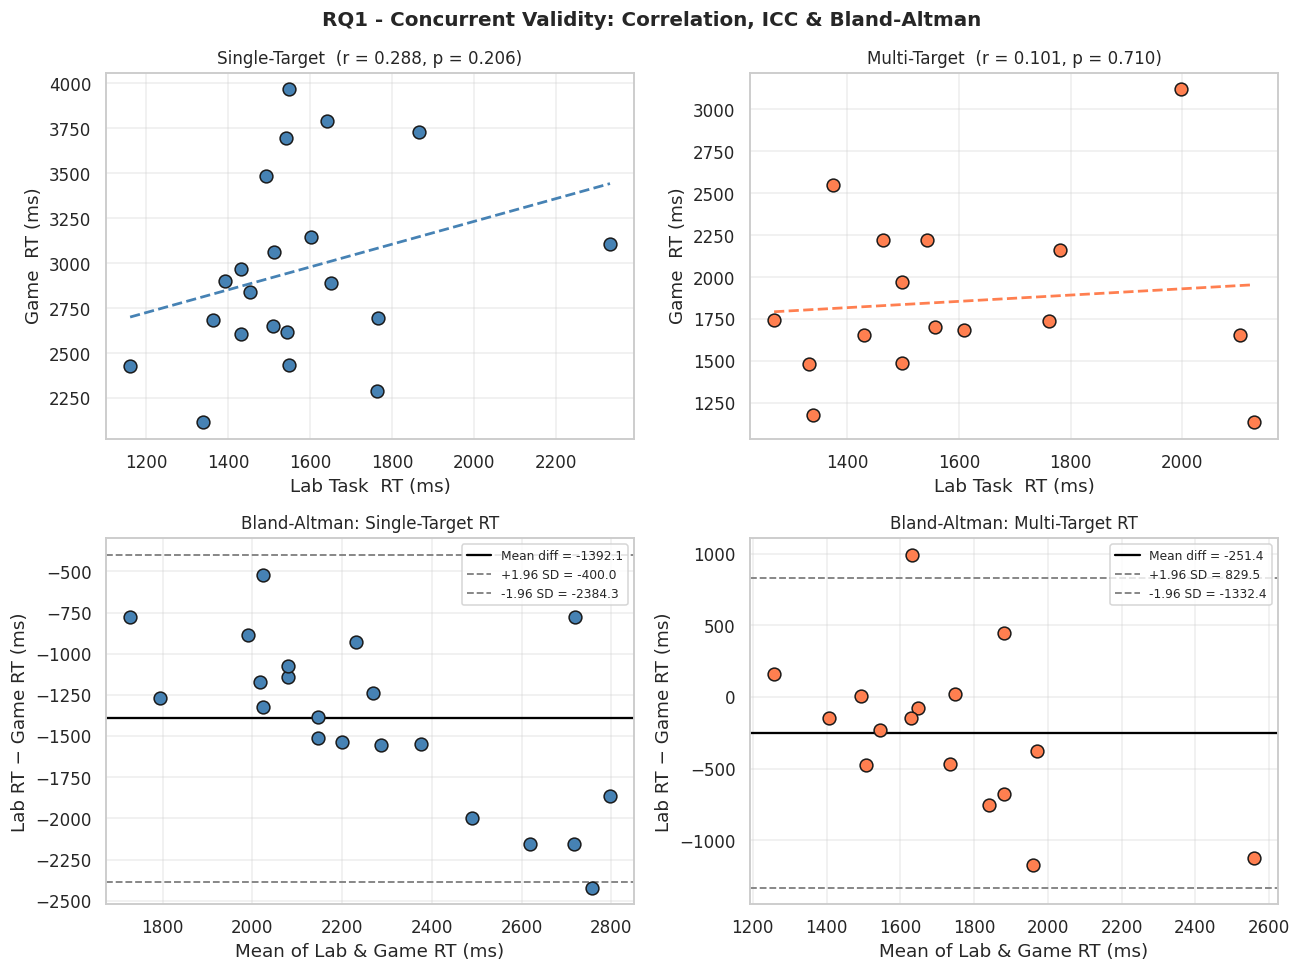

In [90]:
import warnings
from statsmodels.stats.multitest import multipletests

def run_correlation(df_wide, label, dv="RT"):
    col_lab  = f"{dv}_Lab"
    col_game = f"{dv}_Game"
    x, y = df_wide[col_lab].values, df_wide[col_game].values

    if np.std(x) == 0 or np.std(y) == 0:
        print(f"\n  {label}  -  DV: {dv} SKIPPED (constant variable; no variance to correlate)")
        return np.nan, np.nan, np.nan, np.nan

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r_p, p_p = stats.pearsonr(x, y)
        r_s, p_s = stats.spearmanr(x, y)

    n = len(x)
    print(f"\n{'─'*55}")
    print(f"  {label}  (n = {n})  -  DV: {dv}")
    print(f"{'─'*55}")
    print(f"  Pearson  r = {r_p:+.3f},  p = {p_p:.4f}  {'* p<.05' if p_p<.05 else 'ns'}")
    print(f"  Spearman rho = {r_s:+.3f},  p = {p_s:.4f}  {'* p<.05' if p_s<.05 else 'ns'}")
    return r_p, p_p, r_s, p_s

# ── 1. Shapiro-Wilk normality check ──
print("=" * 60)
print("  SHAPIRO-WILK NORMALITY CHECK (before correlations)")
print("=" * 60)
shapiro_rows = []
for grp in ["Single", "Multi"]:
    for var in ["RT_Lab", "RT_Game"]:
        sub = wide_df[wide_df.group == grp][var].dropna()
        if len(sub) >= 3 and sub.std() > 0:
            w, p = stats.shapiro(sub)
            normal = "Yes" if p > 0.05 else "No"
            shapiro_rows.append({"Group": grp, "Variable": var, "W": round(w, 3), "p": round(p, 4), "Normal?": normal})
shapiro_df = pd.DataFrame(shapiro_rows)
display(shapiro_df)

# ── 2. Correlations (Pearson + Spearman printed prominently) ──
print("\n" + "=" * 55)
print("  CONCURRENT VALIDITY - Game vs Lab correlations")
print("=" * 55)

print("\n--- Reaction Time ---")
run_correlation(wide_df[wide_df.group=="Single"], "Single-Target Group", dv="RT")
run_correlation(wide_df[wide_df.group=="Multi"],  "Multi-Target Group",  dv="RT")

print("\n--- Accuracy ---")
print("  Note: Lab accuracy = 100% for all Single participants (zero variance).")
print("  Correlation with Lab Acc is undefined; Game accuracy shown below:")
for grp in ["Single","Multi"]:
    sub = wide_df[wide_df.group==grp]
    print(f"    {grp} Game Acc: M = {sub.Acc_Game.mean():.2f}%, SD = {sub.Acc_Game.std():.2f}%")

# ── 3. ICC block ──
print("\n" + "=" * 55)
print("  INTRACLASS CORRELATION (ICC)")
print("=" * 55)
for grp in ["Single", "Multi"]:
    sub_wide = wide_df[wide_df.group == grp].copy()
    # Build long-format for ICC
    long_icc = pd.DataFrame({
        "pid": list(sub_wide.pid) * 2,
        "modality": ["Lab"] * len(sub_wide) + ["Game"] * len(sub_wide),
        "RT": list(sub_wide.RT_Lab) + list(sub_wide.RT_Game)
    })
    try:
        icc_res = pg.intraclass_corr(data=long_icc, targets="pid", raters="modality", ratings="RT")
        icc2_row = icc_res[icc_res["Type"] == "ICC2"]
        if not icc2_row.empty:
            icc_val = icc2_row["ICC"].values[0]
            ci_low = icc2_row["CI95%"].values[0][0]
            ci_high = icc2_row["CI95%"].values[0][1]
            p_val = icc2_row["pval"].values[0]
            print(f"\n  {grp}-Target Group - RT:")
            print(f"    ICC2 = {icc_val:.3f},  95% CI = [{ci_low:.3f}, {ci_high:.3f}],  p = {p_val:.4f}")
    except Exception as e:
        print(f"\n  {grp}-Target Group - RT: ICC computation failed ({e})")
    
    # Accuracy ICC (skip single lab since SD=0)
    if grp == "Multi":
        long_icc_acc = pd.DataFrame({
            "pid": list(sub_wide.pid) * 2,
            "modality": ["Lab"] * len(sub_wide) + ["Game"] * len(sub_wide),
            "Acc": list(sub_wide.Acc_Lab) + list(sub_wide.Acc_Game)
        })
        if long_icc_acc["Acc"].std() > 0:
            try:
                icc_res_acc = pg.intraclass_corr(data=long_icc_acc, targets="pid", raters="modality", ratings="Acc")
                icc2_row_acc = icc_res_acc[icc_res_acc["Type"] == "ICC2"]
                if not icc2_row_acc.empty:
                    print(f"\n  {grp}-Target Group - Accuracy:")
                    print(f"    ICC2 = {icc2_row_acc['ICC'].values[0]:.3f},  95% CI = [{icc2_row_acc['CI95%'].values[0][0]:.3f}, {icc2_row_acc['CI95%'].values[0][1]:.3f}],  p = {icc2_row_acc['pval'].values[0]:.4f}")
            except Exception as e:
                print(f"\n  {grp}-Target Group - Accuracy: ICC computation failed ({e})")

# ── 4. Combined figure: scatterplots (row 1) + Bland-Altman (row 2) ──
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Row 1: Scatterplots
for ax, grp, color in zip(axes[0], ["Single","Multi"], ["steelblue","coral"]):
    sub = wide_df[wide_df.group==grp]
    ax.scatter(sub.RT_Lab, sub.RT_Game, color=color, edgecolors="k", s=70, zorder=3)
    m, b = np.polyfit(sub.RT_Lab, sub.RT_Game, 1)
    xl = np.array([sub.RT_Lab.min(), sub.RT_Lab.max()])
    ax.plot(xl, m*xl+b, color=color, lw=1.8, ls="--")
    r, p = stats.pearsonr(sub.RT_Lab, sub.RT_Game)
    ax.set_title(f"{grp}-Target  (r = {r:.3f}, p = {p:.3f})", fontsize=11)
    ax.set_xlabel("Lab Task  RT (ms)")
    ax.set_ylabel("Game  RT (ms)")
    ax.grid(alpha=.35)

# Row 2: Bland-Altman
for ax, grp, color in zip(axes[1], ["Single","Multi"], ["steelblue","coral"]):
    sub = wide_df[wide_df.group==grp]
    mean_vals = (sub.RT_Lab + sub.RT_Game) / 2
    diff_vals = sub.RT_Lab - sub.RT_Game
    mean_diff = diff_vals.mean()
    std_diff = diff_vals.std()
    ax.scatter(mean_vals, diff_vals, color=color, edgecolors="k", s=70, zorder=3)
    ax.axhline(mean_diff, color="black", lw=1.5, ls="-", label=f"Mean diff = {mean_diff:.1f}")
    ax.axhline(mean_diff + 1.96*std_diff, color="grey", lw=1.2, ls="--", label=f"+1.96 SD = {mean_diff+1.96*std_diff:.1f}")
    ax.axhline(mean_diff - 1.96*std_diff, color="grey", lw=1.2, ls="--", label=f"-1.96 SD = {mean_diff-1.96*std_diff:.1f}")
    ax.set_title(f"Bland-Altman: {grp}-Target RT", fontsize=11)
    ax.set_xlabel("Mean of Lab & Game RT (ms)")
    ax.set_ylabel("Lab RT − Game RT (ms)")
    ax.legend(fontsize=8)
    ax.grid(alpha=.35)

fig.suptitle("RQ1 - Concurrent Validity: Correlation, ICC & Bland-Altman", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("fig_rq1_concurrent_validity_icc.png", bbox_inches="tight")
plt.show()


## Section 5 - RQ2 & RQ3: Mixed 2 × 2 ANOVA

- **RQ2:** Single vs Multiple Target Load (between factor)  
- **RQ3:** Game vs Lab Modality (within factor)  
- **Interaction:** Does the modality effect depend on target load?

  ASSUMPTION CHECKS - Shapiro-Wilk normality per cell


,Group,Modality,DV,W,p,Pass/Fail
0,Single,Lab,RT,0.869,0.0092,Fail
1,Single,Lab,Acc,0.815,0.0011,Fail
2,Single,Game,RT,0.946,0.2869,Pass
3,Single,Game,Acc,0.762,0.0002,Fail
4,Multi,Lab,RT,0.891,0.0579,Pass
5,Multi,Lab,Acc,0.967,0.7882,Pass
6,Multi,Game,RT,0.926,0.2124,Pass
7,Multi,Game,Acc,0.962,0.6981,Pass



  Levene's Test - homogeneity of variance (between-subjects factor)


,Modality,DV,Levene F,p,Homogeneous?
0,Lab,RT,0.747,0.3933,Yes
1,Lab,Acc,0.049,0.8257,Yes
2,Game,RT,0.164,0.6882,Yes
3,Game,Acc,2.643,0.1130,Yes



  Mauchly's test not required: Modality has only 2 levels → sphericity assumption trivially met.

  Mixed ANOVA  -  DV: Reaction Time (ms)


...

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,Single,Multi,2957.554876,1856.455654,1101.099223,170.294181,6.465865,32.868463,2.510237e-07,2.091666



  Modality=Game, DV=Acc:


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,Single,Multi,95.787341,96.372026,-0.584685,1.369666,-0.426882,29.457902,0.672569,-0.126509



  Bonferroni Correction - Paired t-test p-values


,Comparison,Original p,Bonferroni p,Significant?
0,Single - RT,0.0000,0.0000,Yes
1,Single - Acc,0.0109,0.0435,Yes
2,Multi - RT,0.0882,0.3529,No
3,Multi - Acc,0.0000,0.0000,Yes


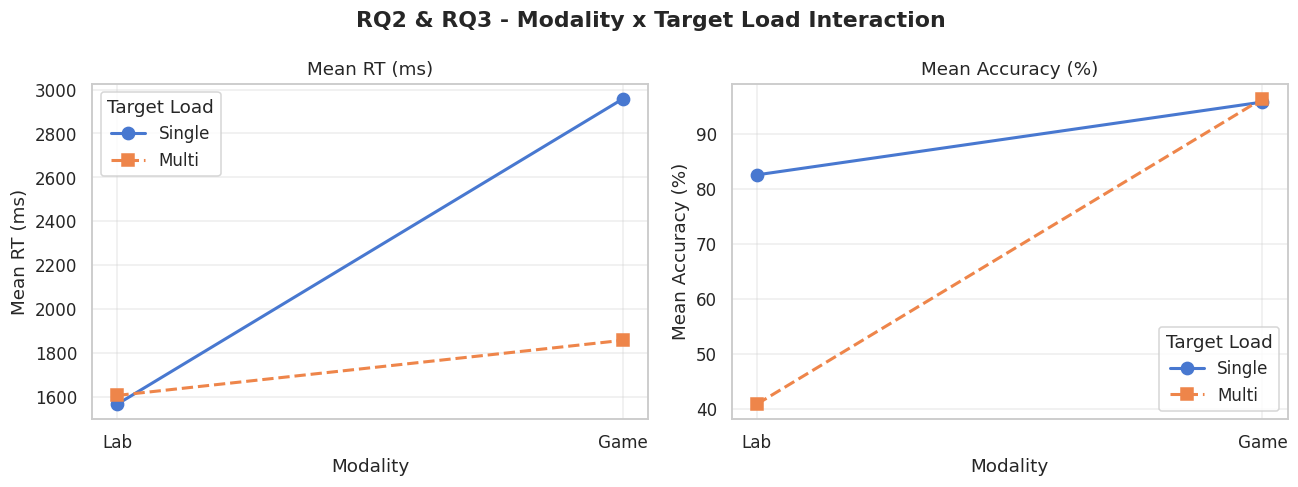

In [91]:
import warnings
warnings.filterwarnings("ignore", message="Precision loss", category=RuntimeWarning)

from statsmodels.stats.multitest import multipletests

# ── 1. Shapiro-Wilk per cell (standalone block BEFORE ANOVA) ──
print("=" * 65)
print("  ASSUMPTION CHECKS - Shapiro-Wilk normality per cell")
print("=" * 65)
shapiro_rows = []
for grp in ["Single", "Multi"]:
    for mod in ["Lab", "Game"]:
        for dv, dv_label in [("mean_RT", "RT"), ("mean_Acc", "Acc")]:
            sub = long_df[(long_df.group==grp) & (long_df.modality==mod)][dv].dropna()
            if len(sub) >= 3 and sub.std() > 0:
                w, p = stats.shapiro(sub)
                shapiro_rows.append({
                    "Group": grp, "Modality": mod, "DV": dv_label,
                    "W": round(w, 3), "p": round(p, 4),
                    "Pass/Fail": "Pass" if p > 0.05 else "Fail"
                })
display(pd.DataFrame(shapiro_rows))

# ── 2. Levene's test for homogeneity of variance ──
print("\n" + "=" * 65)
print("  Levene's Test - homogeneity of variance (between-subjects factor)")
print("=" * 65)
levene_rows = []
for mod in ["Lab", "Game"]:
    for dv, dv_label in [("mean_RT", "RT"), ("mean_Acc", "Acc")]:
        a = long_df[(long_df.modality==mod) & (long_df.group=="Single")][dv].dropna()
        b = long_df[(long_df.modality==mod) & (long_df.group=="Multi")][dv].dropna()
        if a.std() > 0 and b.std() > 0:
            F, p = stats.levene(a, b)
            homo = "Yes" if p > 0.05 else "No"
            levene_rows.append({"Modality": mod, "DV": dv_label, "Levene F": round(F, 3), "p": round(p, 4), "Homogeneous?": homo})
display(pd.DataFrame(levene_rows))
if any(r["Homogeneous?"] == "No" for r in levene_rows):
    print("  NOTE: Some cells violate homogeneity → Welch-corrected independent t-tests (Section 6) are appropriate.")

# ── 3. Sphericity statement ──
print("\n  Mauchly's test not required: Modality has only 2 levels → sphericity assumption trivially met.")

# ── Mixed ANOVA (existing) ──
def run_mixed_anova(long, dv_col, dv_label):
    aov = pg.mixed_anova(
        data=long,
        dv=dv_col,
        within="modality",
        between="group",
        subject="pid"
    )
    print(f"\n{'='*65}")
    print(f"  Mixed ANOVA  -  DV: {dv_label}")
    print(f"{'='*65}")
    display(aov.round(4))
    return aov

long_df_reset = long_df.copy()
aov_rt  = run_mixed_anova(long_df_reset, "mean_RT",  "Reaction Time (ms)")
aov_acc = run_mixed_anova(long_df_reset, "mean_Acc", "Accuracy (%)")

# ── 4. Games-Howell post-hoc ──
print("\n" + "=" * 65)
print("  Games-Howell Post-Hoc Tests (Target Load main effect)")
print("=" * 65)
for mod in ["Lab", "Game"]:
    for dv, dv_label in [("mean_RT", "RT"), ("mean_Acc", "Acc")]:
        sub = long_df_reset[long_df_reset.modality == mod]
        if sub[dv].std() > 0:
            try:
                gh = pg.pairwise_gameshowell(data=sub, dv=dv, between="group")
                print(f"\n  Modality={mod}, DV={dv_label}:")
                display(gh)
            except Exception as e:
                print(f"\n  Modality={mod}, DV={dv_label}: Games-Howell failed ({e})")

# ── 5. Bonferroni correction for paired t-tests ──
print("\n" + "=" * 65)
print("  Bonferroni Correction - Paired t-test p-values")
print("=" * 65)
paired_pvals = []
paired_labels = []
for grp in ["Single", "Multi"]:
    sub = wide_df[wide_df.group == grp]
    for dv in ["RT", "Acc"]:
        t_val, p_val = stats.ttest_rel(sub[f"{dv}_Lab"], sub[f"{dv}_Game"])
        paired_pvals.append(p_val)
        paired_labels.append(f"{grp} - {dv}")
reject, corrected, _, _ = multipletests(paired_pvals, method="bonferroni")
bonf_df = pd.DataFrame({
    "Comparison": paired_labels,
    "Original p": [round(p, 4) for p in paired_pvals],
    "Bonferroni p": [round(p, 4) for p in corrected],
    "Significant?": ["Yes" if r else "No" for r in reject]
})
display(bonf_df)

# ── 6. Interaction plot with significance asterisks ──
def sig_stars(p):
    if p < .001: return "***"
    if p < .01: return "**"
    if p < .05: return "*"
    return "ns"

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, title in zip(axes, ["mean_RT","mean_Acc"], ["Mean RT (ms)","Mean Accuracy (%)"]):
    cell_means = long_df_reset.groupby(["group","modality"], observed=True)[col].mean().reset_index()
    for grp, ls in [("Single","o-"),("Multi","s--")]:
        sub = cell_means[cell_means.group==grp].sort_values("modality")
        ax.plot(sub["modality"].astype(str), sub[col], ls, label=grp, ms=8, lw=2)
    ax.set_title(title)
    ax.set_xlabel("Modality")
    ax.set_ylabel(title)
    ax.legend(title="Target Load")
    ax.grid(alpha=.35)

fig.suptitle("RQ2 & RQ3 - Modality x Target Load Interaction", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_rq2_rq3_anova_with_assumptions.png", bbox_inches="tight")
plt.show()


## Section 6 - Pairwise Tests

In [92]:
import warnings
warnings.filterwarnings("ignore", message="Precision loss", category=RuntimeWarning)

def cohens_d_paired(a, b):
    diff = np.array(a) - np.array(b)
    return diff.mean() / diff.std(ddof=1)

def cohens_d_indep(a, b):
    na, nb = len(a), len(b)
    pooled_sd = np.sqrt(((na-1)*np.std(a,ddof=1)**2 + (nb-1)*np.std(b,ddof=1)**2) / (na+nb-2))
    return (np.mean(a) - np.mean(b)) / pooled_sd

def report_ttest(label, t, p, d, df, kind="paired"):
    sig = "✓ p < .05" if p < .05 else "ns"
    print(f"  {label}")
    print(f"    t({df:.0f}) = {t:+.3f},  p = {p:.4f}  [{sig}],  Cohen's d = {d:.3f}")
    print()

print("=" * 65)
print("  SECTION 6a - PAIRED t-tests: Game vs Lab (within groups)")
print("  DV: Reaction Time (ms)")
print("=" * 65)
for grp in ["Single","Multi"]:
    sub = wide_df[wide_df.group==grp]
    t, p = stats.ttest_rel(sub.RT_Lab, sub.RT_Game)
    d    = cohens_d_paired(sub.RT_Lab, sub.RT_Game)
    report_ttest(f"{grp}-Target  (n = {len(sub)})", t, p, d, len(sub)-1)

print("  DV: Accuracy (%)")
print("-" * 65)
for grp in ["Single","Multi"]:
    sub = wide_df[wide_df.group==grp]
    t, p = stats.ttest_rel(sub.Acc_Lab, sub.Acc_Game)
    d    = cohens_d_paired(sub.Acc_Lab, sub.Acc_Game)
    report_ttest(f"{grp}-Target  (n = {len(sub)})", t, p, d, len(sub)-1)

print("\n" + "=" * 65)
print("  SECTION 6b  -  INDEPENDENT t-tests: Single vs Multi")
print("  DV: Reaction Time (ms)")
print("=" * 65)
for mod in ["Lab","Game"]:
    a = wide_df[wide_df.group=="Single"][f"RT_{mod}"].values
    b = wide_df[wide_df.group=="Multi" ][f"RT_{mod}"].values
    t, p = stats.ttest_ind(a, b, equal_var=False)  # Welch's
    d    = cohens_d_indep(a, b)
    df_w = (np.var(a,ddof=1)/len(a) + np.var(b,ddof=1)/len(b))**2 / \
           ((np.var(a,ddof=1)/len(a))**2/(len(a)-1) + (np.var(b,ddof=1)/len(b))**2/(len(b)-1))
    report_ttest(f"{mod} Task  (n_single={len(a)}, n_multi={len(b)})", t, p, d, df_w, kind="indep")

print("  DV: Accuracy (%)")
print("-" * 65)
for mod in ["Lab","Game"]:
    a = wide_df[wide_df.group=="Single"][f"Acc_{mod}"].values
    b = wide_df[wide_df.group=="Multi" ][f"Acc_{mod}"].values
    t, p = stats.ttest_ind(a, b, equal_var=False)
    d    = cohens_d_indep(a, b)
    df_w = (np.var(a,ddof=1)/len(a) + np.var(b,ddof=1)/len(b))**2 / \
           ((np.var(a,ddof=1)/len(a))**2/(len(a)-1) + (np.var(b,ddof=1)/len(b))**2/(len(b)-1))
    report_ttest(f"{mod} Task  (n_single={len(a)}, n_multi={len(b)})", t, p, d, df_w, kind="indep")

# ── Bonferroni correction summary table ──
from statsmodels.stats.multitest import multipletests

print("\n" + "=" * 75)
print("  BONFERRONI CORRECTION SUMMARY")
print("=" * 75)

# Collect paired t-test p-values
paired_info = []
for grp in ["Single","Multi"]:
    sub = wide_df[wide_df.group==grp]
    for dv in ["RT","Acc"]:
        t_val, p_val = stats.ttest_rel(sub[f"{dv}_Lab"], sub[f"{dv}_Game"])
        diff = np.array(sub[f"{dv}_Lab"]) - np.array(sub[f"{dv}_Game"])
        d = diff.mean() / diff.std(ddof=1)
        paired_info.append({"Comparison": f"{grp} Lab vs Game", "DV": dv, "t": round(t_val, 3),
                            "df": len(sub)-1, "Original p": round(p_val, 4), "Cohen d": round(d, 3)})

paired_pvals = [r["Original p"] for r in paired_info]
reject_p, corrected_p, _, _ = multipletests(paired_pvals, method="bonferroni")
for i, r in enumerate(paired_info):
    r["Corrected p"] = round(corrected_p[i], 4)
    r["Significant?"] = "Yes" if reject_p[i] else "No"

print("\n  Paired t-tests:")
display(pd.DataFrame(paired_info))

# Collect independent t-test p-values
indep_info = []
for mod in ["Lab","Game"]:
    for dv in ["RT","Acc"]:
        a = wide_df[wide_df.group=="Single"][f"{dv}_{mod}"].values
        b = wide_df[wide_df.group=="Multi"][f"{dv}_{mod}"].values
        t_val, p_val = stats.ttest_ind(a, b, equal_var=False)
        na, nb = len(a), len(b)
        pooled_sd = np.sqrt(((na-1)*np.std(a,ddof=1)**2 + (nb-1)*np.std(b,ddof=1)**2) / (na+nb-2))
        d = (np.mean(a) - np.mean(b)) / pooled_sd if pooled_sd > 0 else np.nan
        df_w = (np.var(a,ddof=1)/na + np.var(b,ddof=1)/nb)**2 / \
               ((np.var(a,ddof=1)/na)**2/(na-1) + (np.var(b,ddof=1)/nb)**2/(nb-1))
        indep_info.append({"Comparison": f"Single vs Multi ({mod})", "DV": dv, "t": round(t_val, 3),
                           "df": round(df_w, 0), "Original p": round(p_val, 4), "Cohen d": round(d, 3)})

indep_pvals = [r["Original p"] for r in indep_info]
reject_i, corrected_i, _, _ = multipletests(indep_pvals, method="bonferroni")
for i, r in enumerate(indep_info):
    r["Corrected p"] = round(corrected_i[i], 4)
    r["Significant?"] = "Yes" if reject_i[i] else "No"

print("\n  Independent t-tests:")
display(pd.DataFrame(indep_info))


  SECTION 6a - PAIRED t-tests: Game vs Lab (within groups)
  DV: Reaction Time (ms)
  Single-Target  (n = 21)
    t(20) = -12.603,  p = 0.0000  [✓ p < .05],  Cohen's d = -2.750

  Multi-Target  (n = 16)
    t(15) = -1.823,  p = 0.0882  [ns],  Cohen's d = -0.456

  DV: Accuracy (%)
-----------------------------------------------------------------
  Single-Target  (n = 21)
    t(20) = -2.807,  p = 0.0109  [✓ p < .05],  Cohen's d = -0.613

  Multi-Target  (n = 16)
    t(15) = -9.943,  p = 0.0000  [✓ p < .05],  Cohen's d = -2.486


  SECTION 6b  -  INDEPENDENT t-tests: Single vs Multi
  DV: Reaction Time (ms)
  Lab Task  (n_single=21, n_multi=16)
    t(30) = -0.462,  p = 0.6471  [ns],  Cohen's d = -0.157

  Game Task  (n_single=21, n_multi=16)
    t(33) = +6.466,  p = 0.0000  [✓ p < .05],  Cohen's d = 2.138

  DV: Accuracy (%)
-----------------------------------------------------------------
  Lab Task  (n_single=21, n_multi=16)
    t(31) = +6.133,  p = 0.0000  [✓ p < .05],  Cohen's d = 2.

,Comparison,DV,t,df,Original p,Cohen d,Corrected p,Significant?
0,Single Lab vs Game,RT,-12.603,20,0.0000,-2.750,0.0000,Yes
1,Single Lab vs Game,Acc,-2.807,20,0.0109,-0.613,0.0436,Yes
2,Multi Lab vs Game,RT,-1.823,15,0.0882,-0.456,0.3528,No
3,Multi Lab vs Game,Acc,-9.943,15,0.0000,-2.486,0.0000,Yes



  Independent t-tests:


,Comparison,DV,t,df,Original p,Cohen d,Corrected p,Significant?
0,Single vs Multi (Lab),RT,-0.462,30.0,0.6471,-0.157,1.0,No
1,Single vs Multi (Lab),Acc,6.133,31.0,0.0000,2.054,0.0,Yes
2,Single vs Multi (Game),RT,6.466,33.0,0.0000,2.138,0.0,Yes
3,Single vs Multi (Game),Acc,-0.427,29.0,0.6726,-0.129,1.0,No


## Section 7 - RQ4: Effect of Level in the Game

Level observations: 546
Levels present: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]

  Linear trend: RT_ms ~ Level  (OLS per group)

  Single-Target  (N obs = 351)
    β(level) = +261.25 ms/level, intercept = 861.8
    r = 0.445,  r² = 0.198,  p = 0.0000  ✓

  Multi-Target  (N obs = 195)
    β(level) = -25.11 ms/level, intercept = 1996.0
    r = -0.061,  r² = 0.004,  p = 0.3956  ns

  One-way ANOVA (levels 1-10, pooled): F = 6.263, p = 0.0000


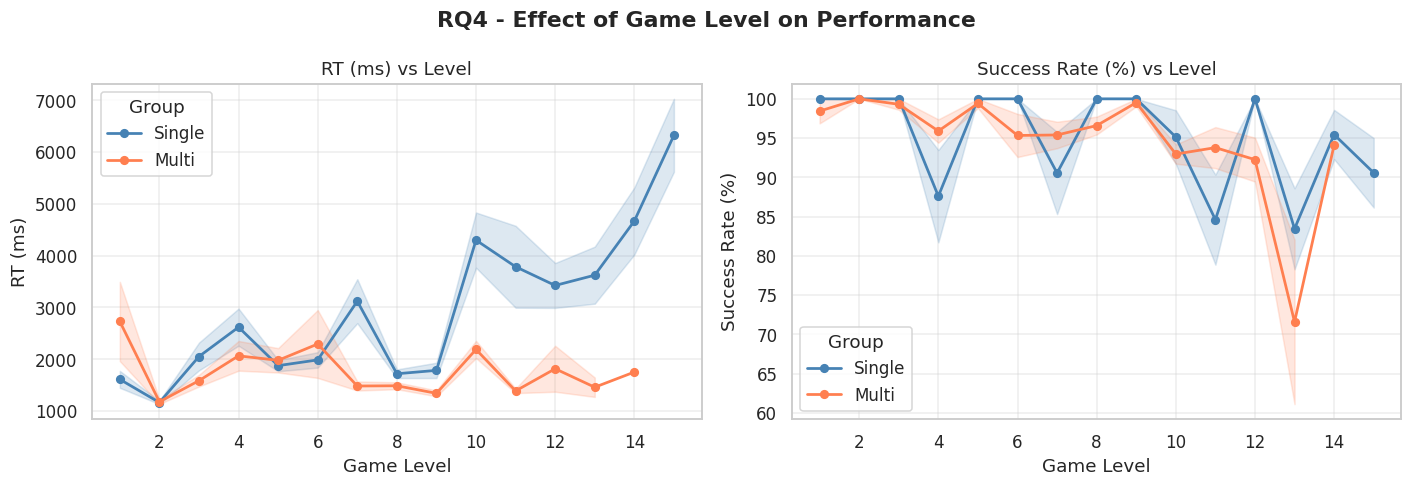


  Quadratic regression & AIC comparison

  Single-Target Group:
    Linear AIC  = 6422.13
    Quadratic AIC = 6414.90
    Preferred: Quadratic

  Multi-Target Group:
    Linear AIC  = 3375.45
    Quadratic AIC = 3377.09
    Preferred: Linear

  Repeated-Measures ANOVA across levels (per group)

  Single-Target Group (levels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]):


,Source,ddof1,ddof2,F,p_unc,p_GG_corr,ng2,eps,sphericity,W_spher,p_spher
0,level,14,280,12.751942,4.637308e-23,1.664106e-10,0.370595,0.400421,False,2.504570e-09,7.208319e-20



  Multi-Target Group (levels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]):


,Source,ddof1,ddof2,F,p_unc,p_GG_corr,ng2,eps,sphericity,W_spher,p_spher
0,level,9,135,2.487313,0.01163,0.096597,0.120348,0.234616,False,3.396333e-08,2.478901e-21


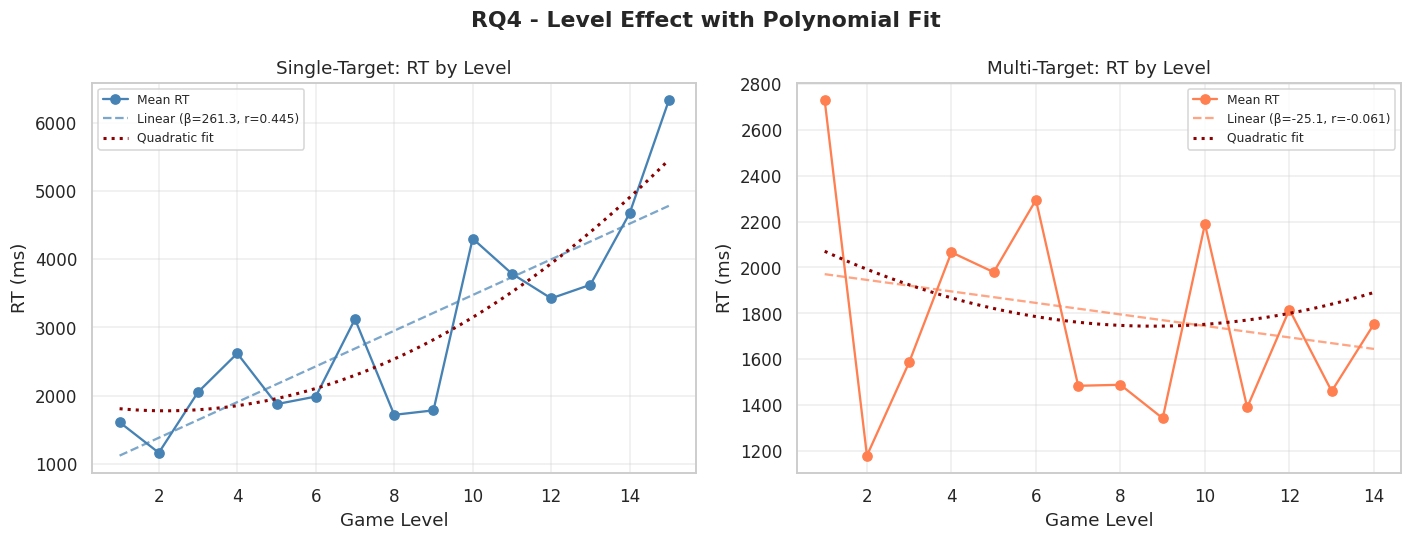

In [93]:
def build_level_df(raw_dict, group_label):
    frames = []
    for pid, df in raw_dict.items():
        sub = df[["Level","InitialResponseTime(ms)","SuccessRate(%)","HitRate(%)","FalseAlarms"]].copy()
        sub.columns = ["level","RT_ms","SuccessRate","HitRate","FalseAlarms"]
        sub["pid"]   = int(pid)
        sub["group"] = group_label
        frames.append(sub)
    return pd.concat(frames, ignore_index=True)

level_df = pd.concat([
    build_level_df(single_phone_raw, "Single"),
    build_level_df(multi_phone_raw,  "Multi")
], ignore_index=True)

print(f"Level observations: {len(level_df)}")
print(f"Levels present: {sorted(level_df.level.unique())}")

print("\n" + "=" * 60)
print("  Linear trend: RT_ms ~ Level  (OLS per group)")
print("=" * 60)
for grp in ["Single","Multi"]:
    sub = level_df[level_df.group==grp].dropna(subset=["level","RT_ms"])
    slope, intercept, r, p, se = stats.linregress(sub.level, sub.RT_ms)
    print(f"\n  {grp}-Target  (N obs = {len(sub)})")
    print(f"    β(level) = {slope:+.2f} ms/level, intercept = {intercept:.1f}")
    print(f"    r = {r:.3f},  r² = {r**2:.3f},  p = {p:.4f}  {'✓' if p<.05 else 'ns'}")

top10_groups = [level_df[level_df.level==lv]["RT_ms"].dropna().values
                for lv in range(1, 11)]
f_stat, p_aov = stats.f_oneway(*top10_groups)
print(f"\n  One-way ANOVA (levels 1-10, pooled): F = {f_stat:.3f}, p = {p_aov:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, col, ylabel in zip(axes, ["RT_ms","SuccessRate"], ["RT (ms)","Success Rate (%)"]):
    for grp, color in [("Single","steelblue"),("Multi","coral")]:
        sub = level_df[level_df.group==grp].groupby("level")[col].agg(["mean","sem"]).reset_index()
        ax.plot(sub.level, sub["mean"], "o-", color=color, label=grp, ms=5, lw=1.8)
        ax.fill_between(sub.level, sub["mean"] - sub["sem"], sub["mean"] + sub["sem"], color=color, alpha=.18)
    ax.set_xlabel("Game Level")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs Level")
    ax.legend(title="Group")
    ax.grid(alpha=.35)

fig.suptitle("RQ4 - Effect of Game Level on Performance", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_rq4_level_effect_linear.png", bbox_inches="tight")
plt.show()

# ── Quadratic regression and AIC comparison (RQ4 Enhancement) ──
import statsmodels.api as sm

print("\n" + "=" * 60)
print("  Quadratic regression & AIC comparison")
print("=" * 60)
for grp in ["Single", "Multi"]:
    sub = level_df[level_df.group == grp]
    levels = sub["level"].values
    rt_vals = sub["RT_ms"].values
    
    # Linear model
    X_lin = sm.add_constant(levels)
    model_lin = sm.OLS(rt_vals, X_lin).fit()
    
    # Quadratic model  
    levels_sq = levels ** 2
    X_quad = sm.add_constant(np.column_stack([levels, levels_sq]))
    model_quad = sm.OLS(rt_vals, X_quad).fit()
    
    print(f"\n  {grp}-Target Group:")
    print(f"    Linear AIC  = {model_lin.aic:.2f}")
    print(f"    Quadratic AIC = {model_quad.aic:.2f}")
    print(f"    Preferred: {'Quadratic' if model_quad.aic < model_lin.aic else 'Linear'}")

# ── One-way RM-ANOVA across levels ──
print("\n" + "=" * 60)
print("  Repeated-Measures ANOVA across levels (per group)")
print("=" * 60)

for grp in ["Single", "Multi"]:
    sub = level_df[level_df.group == grp][["pid", "level", "RT_ms"]].copy()
    # Only keep levels present for all participants
    level_counts = sub.groupby("level")["pid"].nunique()
    valid_levels = level_counts[level_counts == level_counts.max()].index.tolist()
    sub_balanced = sub[sub["level"].isin(valid_levels)]
    
    if len(valid_levels) >= 3:
        try:
            sub_balanced = sub_balanced.copy()
            sub_balanced["level"] = sub_balanced["level"].astype(str)
            rm_aov = pg.rm_anova(data=sub_balanced, dv="RT_ms", within="level", subject="pid", correction="auto")
            print(f"\n  {grp}-Target Group (levels: {valid_levels}):")
            display(rm_aov)
        except Exception as e:
            print(f"\n  {grp}-Target Group: RM-ANOVA failed ({e})")

# ── Updated level plot with quadratic curve ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, grp, color in zip(axes, ["Single", "Multi"], ["steelblue", "coral"]):
    sub = level_df[level_df.group == grp]
    level_means = sub.groupby("level")["RT_ms"].mean()
    ax.plot(level_means.index, level_means.values, "o-", color=color, label="Mean RT", ms=6, lw=1.5)
    
    # Linear fit
    slope, intercept, r, p, se = stats.linregress(sub["level"], sub["RT_ms"])
    x_fit = np.linspace(sub["level"].min(), sub["level"].max(), 100)
    ax.plot(x_fit, slope * x_fit + intercept, "--", color=color, lw=1.5, alpha=0.7, label=f"Linear (β={slope:.1f}, r={r:.3f})")
    
    # Quadratic fit
    coeffs = np.polyfit(sub["level"], sub["RT_ms"], 2)
    ax.plot(x_fit, np.polyval(coeffs, x_fit), ":", color="darkred", lw=2, label="Quadratic fit")
    
    ax.set_title(f"{grp}-Target: RT by Level")
    ax.set_xlabel("Game Level")
    ax.set_ylabel("RT (ms)")
    ax.legend(fontsize=8)
    ax.grid(alpha=.35)

fig.suptitle("RQ4 - Level Effect with Polynomial Fit", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_rq4_level_effect_with_polynomial.png", bbox_inches="tight")
plt.show()


## Section 8 - Reliability

**Internal consistency** of the game scores is assessed via Cronbach's α computed over level-wise RT values for each participant (items = levels).  
An α ≥ .70 indicates acceptable internal consistency; ≥ .80 is good.

In [94]:
def cronbach_alpha(df_items):
    df_items = df_items.dropna()
    k = df_items.shape[1]
    if k < 2:
        return np.nan
    item_vars = df_items.var(axis=0, ddof=1).sum()
    total_var = df_items.sum(axis=1).var(ddof=1)
    if total_var == 0:
        return np.nan
    return (k / (k - 1)) * (1 - item_vars / total_var)

def split_half_reliability(df_items):
    df_items = df_items.dropna()
    k = df_items.shape[1]
    half1 = df_items.iloc[:, :k//2].sum(axis=1)
    half2 = df_items.iloc[:, k//2:].sum(axis=1)
    r, _ = stats.pearsonr(half1, half2)
    sb = (2 * r) / (1 + r)
    return r, sb

print("=" * 65)
print("  RELIABILITY - Internal Consistency of Game RT (level = item)")
print("=" * 65)

for grp, raw_phone in [("Single", single_phone_raw), ("Multi", multi_phone_raw)]:
    sub = level_df[level_df.group==grp]
    pivot = sub.pivot_table(index="pid", columns="level", values="RT_ms", aggfunc="mean")

    thresh = pivot.shape[0] * 0.5
    pivot = pivot.dropna(thresh=int(thresh), axis=1).dropna(axis=0)

    alpha   = cronbach_alpha(pivot)
    r_sh, sb = split_half_reliability(pivot)

    print(f"\n  {grp}-Target Group  (n={pivot.shape[0]} participants, {pivot.shape[1]} levels as items)")
    print(f"    Chronbach's α (RT) = {alpha:.3f}  {'(good)' if alpha>=.8 else '(acceptable)' if alpha>=.7 else '(poor)'}")
    print(f"    Split-half r = {r_sh:.3f},  Spearman-Brown corrected = {sb:.3f}")

print("\n" + "─" * 65)
print("  Convergent Validity summary (Game vs Lab Pearson r)")
print("─" * 65)
for grp in ["Single","Multi"]:
    sub = wide_df[wide_df.group==grp]
    r, p = stats.pearsonr(sub.RT_Lab, sub.RT_Game)
    print(f"  {grp}: r_converge(RT) = {r:.3f}, p = {p:.4f}")

  RELIABILITY - Internal Consistency of Game RT (level = item)

  Single-Target Group  (n=21 participants, 15 levels as items)
    Chronbach's α (RT) = 0.138  (poor)
    Split-half r = -0.179,  Spearman-Brown corrected = -0.436

  Multi-Target Group  (n=16 participants, 10 levels as items)
    Chronbach's α (RT) = 0.476  (poor)
    Split-half r = 0.430,  Spearman-Brown corrected = 0.601

─────────────────────────────────────────────────────────────────
  Convergent Validity summary (Game vs Lab Pearson r)
─────────────────────────────────────────────────────────────────
  Single: r_converge(RT) = 0.288, p = 0.2055
  Multi: r_converge(RT) = 0.101, p = 0.7096


## Section 9 - Visualisations Summary

Four composite figures:
1. Bar + error chart — M ± SD across the 4 design cells
2. Box plots — RT and Accuracy distributions  
3. Heatmap — Pearson correlation matrix of all four cell scores  
4. Raincloud-style plot — individual data points with distribution

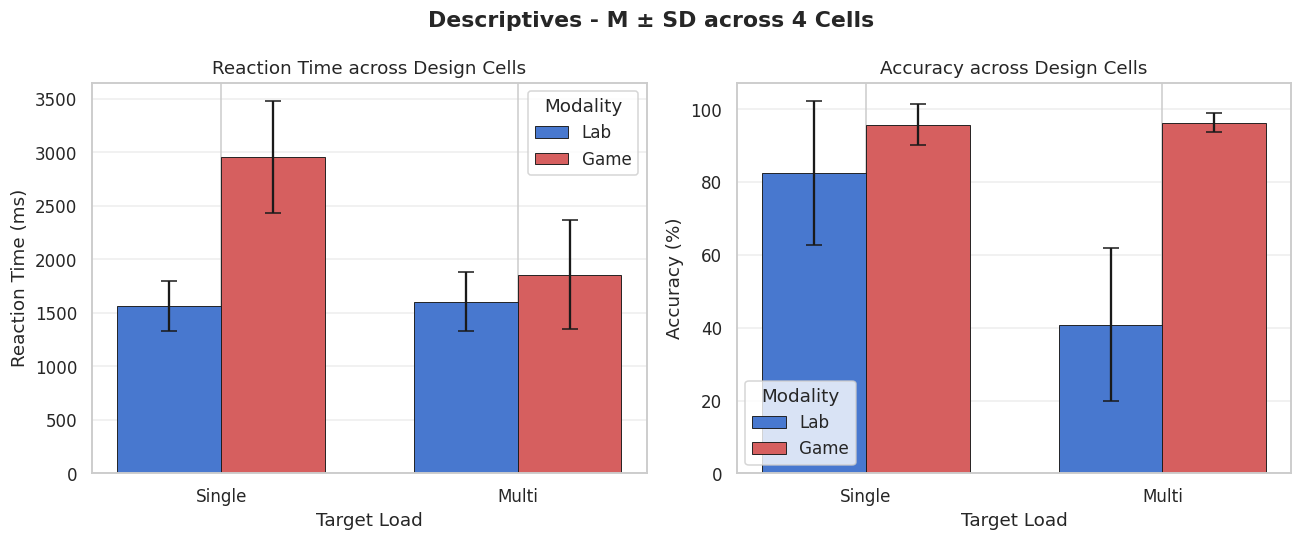

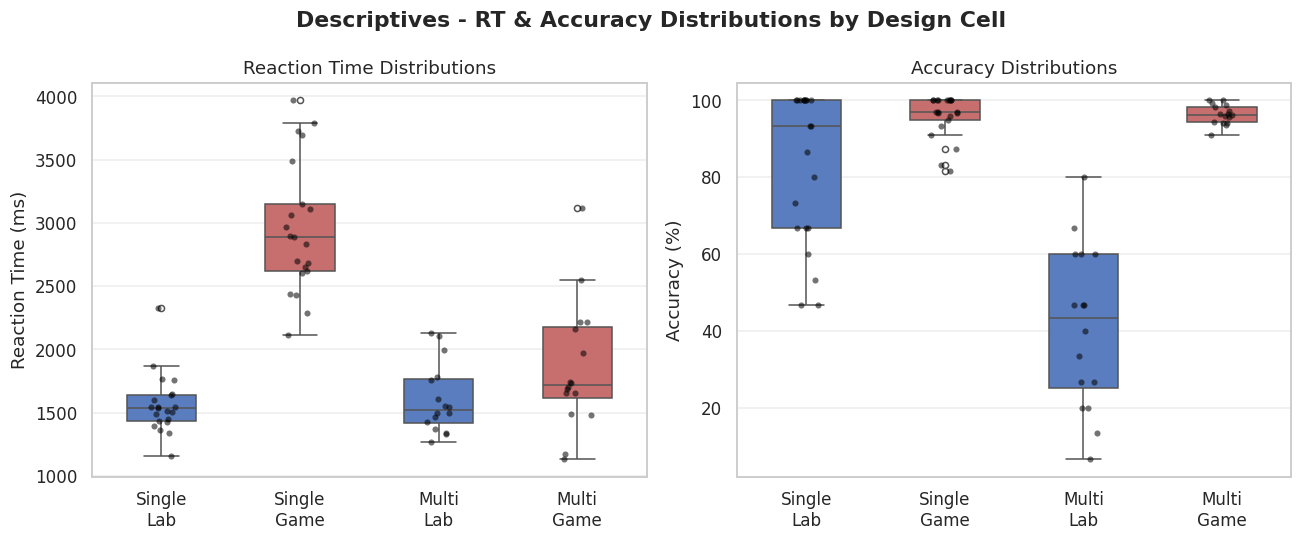

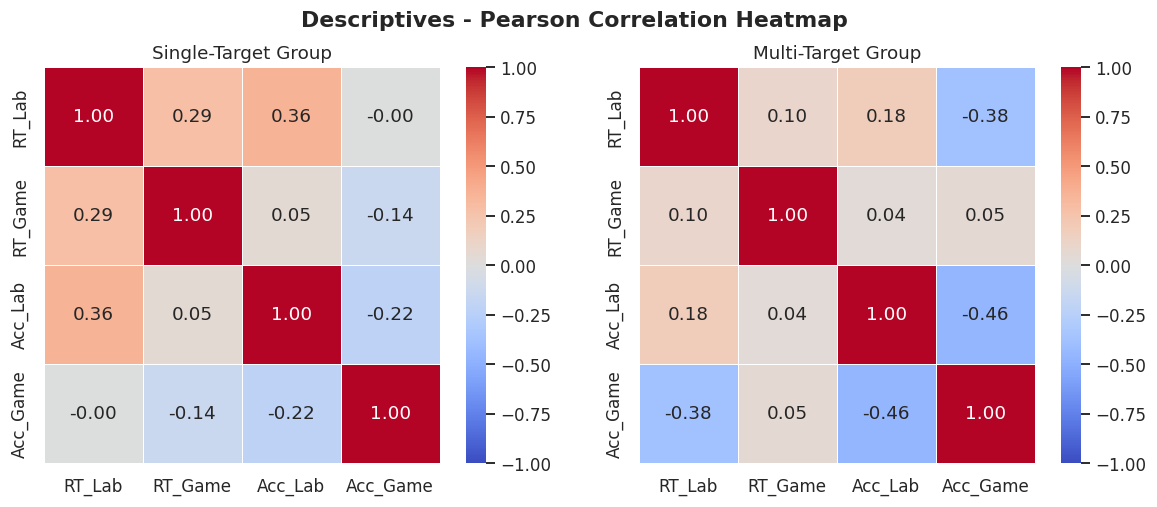

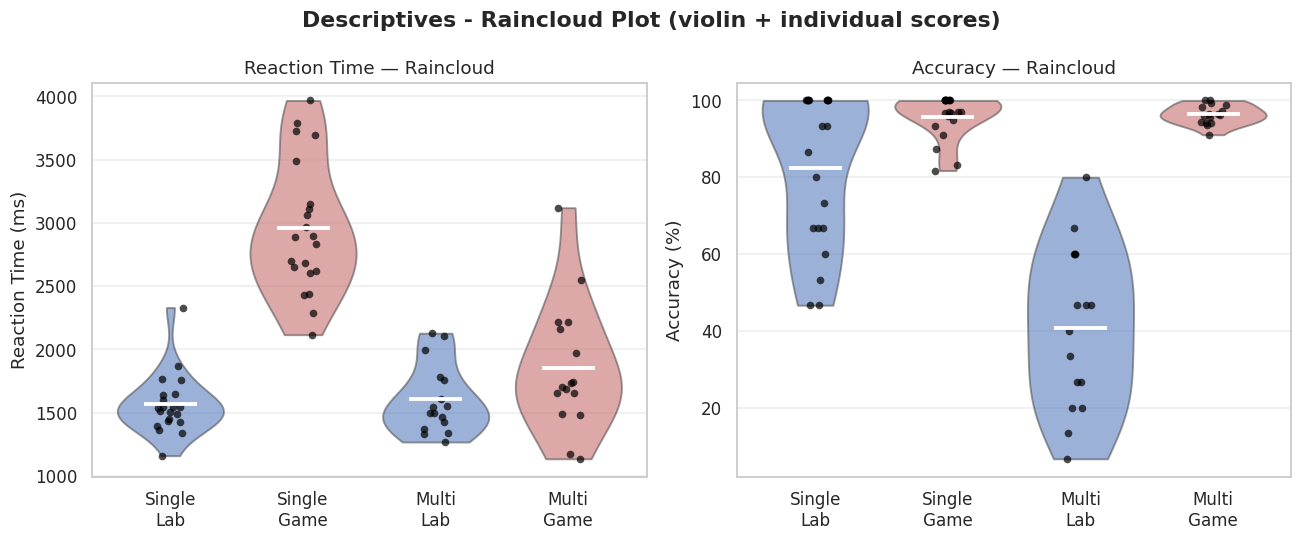

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette = {"Lab":"#4878CF", "Game":"#D65F5F"}

for ax, col, title, unit in zip(axes, ["mean_RT","mean_Acc"], ["Reaction Time","Accuracy"], ["ms","%"]):
    cell_stats = (long_df.groupby(["group","modality"], observed=True)[col].agg(mean="mean", sd="std").reset_index())
    x = np.arange(2)
    width = 0.35
    for i, (mod, color) in enumerate([("Lab","#4878CF"),("Game","#D65F5F")]):
        sub_m = cell_stats[cell_stats.modality==mod].sort_values("group")
        bars = ax.bar(x + i*width, sub_m["mean"], width,
                      label=mod, color=color, edgecolor="k", linewidth=.6,
                      yerr=sub_m["sd"], capsize=5, error_kw=dict(lw=1.5))
    ax.set_xticks(x + width/2)
    ax.set_xticklabels(["Single","Multi"])
    ax.set_xlabel("Target Load")
    ax.set_ylabel(f"{title} ({unit})")
    ax.set_title(f"{title} across Design Cells")
    ax.legend(title="Modality")
    ax.grid(axis="y", alpha=.35)

fig.suptitle("Descriptives - M ± SD across 4 Cells", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_descriptive_bar_cells.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
long_df["cell"] = long_df["group"].astype(str) + "\n" + long_df["modality"].astype(str)
order = ["Single\nLab","Single\nGame","Multi\nLab","Multi\nGame"]
pal   = ["#4878CF","#D65F5F","#4878CF","#D65F5F"]

for ax, col, title, unit in zip(axes, ["mean_RT","mean_Acc"], ["Reaction Time","Accuracy"], ["ms","%"]):
    sns.boxplot(data=long_df, x="cell", y=col, order=order, hue="cell", hue_order=order, palette=pal, width=.5, flierprops=dict(ms=4), legend=False, ax=ax)
    sns.stripplot(data=long_df, x="cell", y=col, order=order, color="black", size=4, alpha=.55, jitter=True, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(f"{title} ({unit})")
    ax.set_title(f"{title} Distributions")
    ax.grid(axis="y", alpha=.35)

fig.suptitle("Descriptives - RT & Accuracy Distributions by Design Cell", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_descriptive_boxplots.png", bbox_inches="tight")
plt.show()

corr_cols = ["RT_Lab","RT_Game","Acc_Lab","Acc_Game"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, grp in zip(axes, ["Single","Multi"]):
    sub = wide_df[wide_df.group==grp][corr_cols]
    corr_mat = sub.corr()
    sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, vmin=-1, vmax=1, ax=ax,
                xticklabels=corr_cols, yticklabels=corr_cols,
                linewidths=.5, square=True)
    ax.set_title(f"{grp}-Target Group")

fig.suptitle("Descriptives - Pearson Correlation Heatmap", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_descriptive_corr_heatmap.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title, unit in zip(axes,
                                  ["mean_RT","mean_Acc"],
                                  ["Reaction Time","Accuracy"],
                                  ["ms","%"]):
    sns.violinplot(data=long_df, x="cell", y=col, order=order, hue="cell", hue_order=order,
                   palette=pal, inner=None, cut=0, alpha=.6, legend=False, ax=ax)
    sns.stripplot(data=long_df, x="cell", y=col, order=order,
                  color="black", size=5, alpha=.7, jitter=True, ax=ax)
    cell_means = long_df.groupby("cell")[col].mean()
    for xi, cell in enumerate(order):
        if cell in cell_means.index:
            ax.hlines(cell_means[cell], xi-.2, xi+.2, colors="white", lw=2.5, zorder=5)
    ax.set_xlabel("")
    ax.set_ylabel(f"{title} ({unit})")
    ax.set_title(f"{title} — Raincloud")
    ax.grid(axis="y", alpha=.35)

fig.suptitle("Descriptives - Raincloud Plot (violin + individual scores)", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_descriptive_raincloud.png", bbox_inches="tight")
plt.show()

## Section 10 - RQ5 (New): Order / Practice Effects

Test whether task order affects RT and Accuracy, verifying counterbalancing effectiveness.

  RQ5 - Order / Practice Effects

  NOTE: Exact session order was not logged. Using participant number
  parity as a proxy: odd PIDs = Game-first, even PIDs = Lab-first.
  This is a LIMITATION of the analysis.

  Single - RT_Game: Game-first (M=2886.0) vs Lab-first (M=3036.3): t=-0.656, p=0.5197
  Single - RT_Lab: Game-first (M=1547.9) vs Lab-first (M=1584.7): t=-0.360, p=0.7240
  Single - Acc_Game: Game-first (M=97.3) vs Lab-first (M=94.1): t=1.331, p=0.1990
  Multi - RT_Game: Game-first (M=1682.7) vs Lab-first (M=2030.2): t=-1.415, p=0.1794
  Multi - RT_Lab: Game-first (M=1537.2) vs Lab-first (M=1672.9): t=-0.992, p=0.3383
  Multi - Acc_Game: Game-first (M=97.0) vs Lab-first (M=95.8): t=0.950, p=0.3594

  Two-way ANOVA: RT_Game ~ group × order


,Source,SS,DF,MS,F,p_unc,np2
0,group,1.111642e+07,1.0,1.111642e+07,42.245776,2.233764e-07,0.561437
1,order,5.133579e+05,1.0,5.133579e+05,1.950917,1.718116e-01,0.055819
2,group * order,8.818244e+04,1.0,8.818244e+04,0.335120,5.665902e-01,0.010053
3,Residual,8.683512e+06,33.0,2.631367e+05,NaN,NaN,NaN



  Two-way ANOVA: Acc_Game ~ group × order


,Source,SS,DF,MS,F,p_unc,np2
0,group,3.717614,1.0,3.717614,0.186725,0.668467,0.005626
1,order,49.872522,1.0,49.872522,2.504950,0.123027,0.070552
2,group * order,8.788114,1.0,8.788114,0.441401,0.511063,0.013199
3,Residual,657.016445,33.0,19.909589,NaN,NaN,NaN


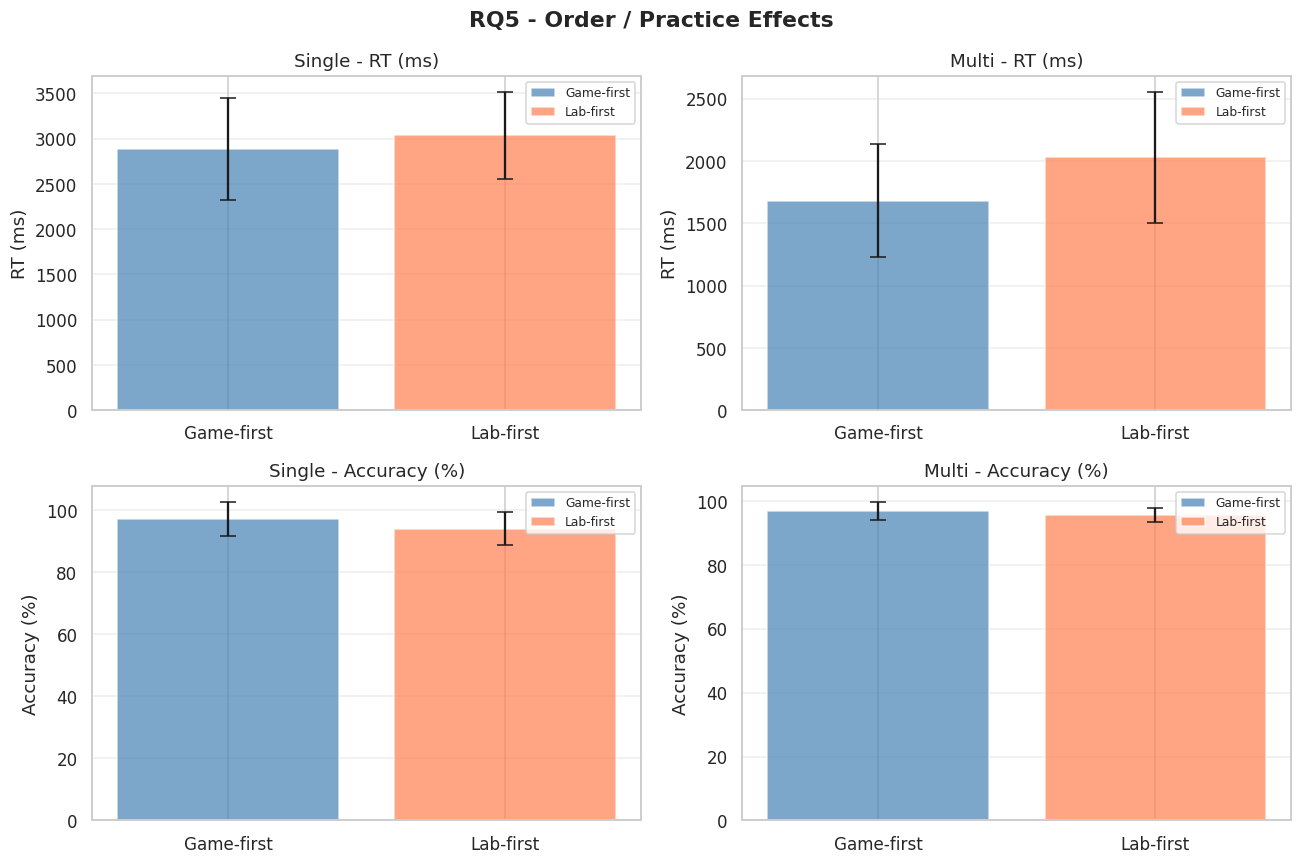

In [96]:
# ── Construct order variable (parity-based proxy) ──
print("=" * 65)
print("  RQ5 - Order / Practice Effects")
print("=" * 65)
print("\n  NOTE: Exact session order was not logged. Using participant number")
print("  parity as a proxy: odd PIDs = Game-first, even PIDs = Lab-first.")
print("  This is a LIMITATION of the analysis.\n")

wide_df["order"] = wide_df["pid"].apply(lambda x: "Game-first" if x % 2 == 1 else "Lab-first")

# Independent t-tests by order
for grp in ["Single", "Multi"]:
    sub = wide_df[wide_df.group == grp]
    for dv in ["RT_Game", "RT_Lab", "Acc_Game"]:
        gf = sub[sub.order == "Game-first"][dv].values
        lf = sub[sub.order == "Lab-first"][dv].values
        if len(gf) >= 2 and len(lf) >= 2:
            t, p = stats.ttest_ind(gf, lf, equal_var=False)
            print(f"  {grp} - {dv}: Game-first (M={gf.mean():.1f}) vs Lab-first (M={lf.mean():.1f}): t={t:.3f}, p={p:.4f}")

# Two-way ANOVA (group × order)
for dv in ["RT_Game", "Acc_Game"]:
    try:
        aov = pg.anova(data=wide_df, dv=dv, between=["group", "order"])
        print(f"\n  Two-way ANOVA: {dv} ~ group × order")
        display(aov)
    except Exception as e:
        print(f"\n  Two-way ANOVA for {dv} failed: {e}")

# ── Plot ──
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, dv, dv_label in [(0, "RT_Game", "RT (ms)"), (1, "Acc_Game", "Accuracy (%)")]:
    for col, grp in [(0, "Single"), (1, "Multi")]:
        ax = axes[row, col]
        sub = wide_df[wide_df.group == grp]
        for order, color in [("Game-first", "steelblue"), ("Lab-first", "coral")]:
            vals = sub[sub.order == order][dv]
            ax.bar(order, vals.mean(), yerr=vals.std(), color=color, alpha=0.7, capsize=5, label=order)
        ax.set_title(f"{grp} - {dv_label}")
        ax.set_ylabel(dv_label)
        ax.legend(fontsize=8)
        ax.grid(alpha=.35, axis="y")

fig.suptitle("RQ5 - Order / Practice Effects", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_rq5_order_practice_effects.png", bbox_inches="tight")
plt.show()


## Section 11 - RQ6 (New): Speed-Accuracy Tradeoff (IES)

Determine whether performance differences reflect genuine cognitive load or a speed-accuracy tradeoff.

  RQ6 - Speed-Accuracy Tradeoff (IES)
  IES_Lab: Single (M=2004.2) vs Multi (M=5890.3): t=-2.821, p=0.0128, Cohen's d=-1.074
  IES_Game: Single (M=3103.6) vs Multi (M=1926.6): t=6.254, p=0.0000, Cohen's d=2.028

  Within-cell Pearson correlations (RT vs Acc):


,Cell,r,p,Interpretation
0,Single-Lab,0.362,0.1067,speed-accuracy tradeoff
1,Single-Game,-0.141,0.5435,genuine load effect
2,Multi-Lab,0.178,0.5084,genuine load effect
3,Multi-Game,0.055,0.8398,genuine load effect


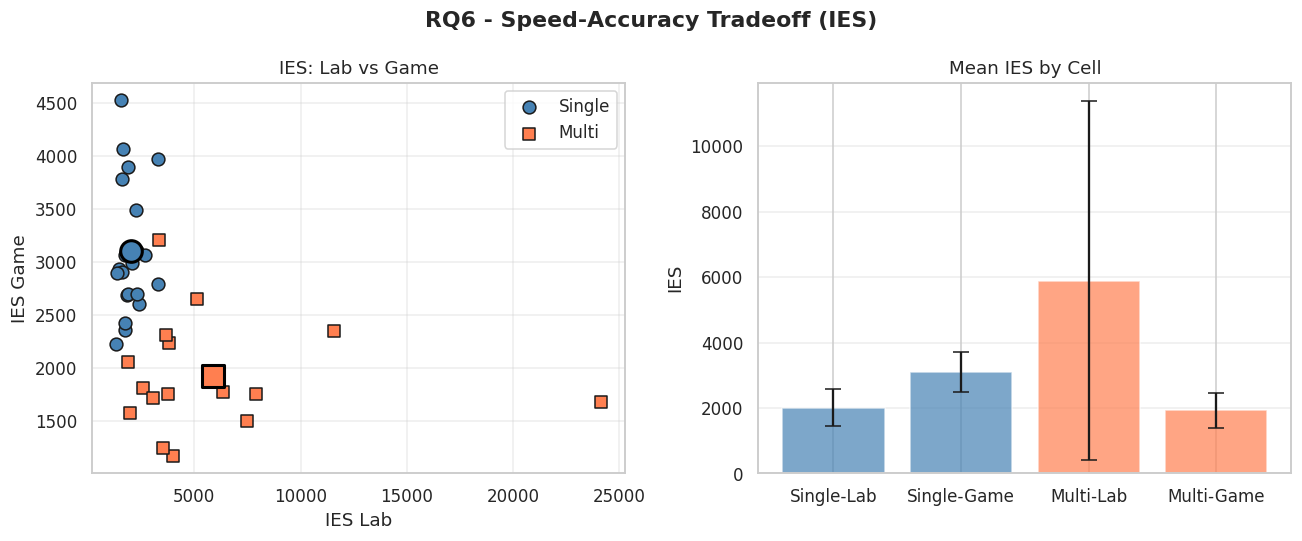

In [97]:
import warnings
warnings.filterwarnings("ignore", message="Precision loss", category=RuntimeWarning)

print("=" * 65)
print("  RQ6 - Speed-Accuracy Tradeoff (IES)")
print("=" * 65)

# Compute IES
wide_df["IES_Lab"] = wide_df["RT_Lab"] / (wide_df["Acc_Lab"] / 100)
wide_df["IES_Game"] = wide_df["RT_Game"] / (wide_df["Acc_Game"] / 100)

# Independent t-tests
for dv in ["IES_Lab", "IES_Game"]:
    a = wide_df[wide_df.group == "Single"][dv].dropna().values
    b = wide_df[wide_df.group == "Multi"][dv].dropna().values
    t, p = stats.ttest_ind(a, b, equal_var=False)
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na-1)*np.std(a,ddof=1)**2 + (nb-1)*np.std(b,ddof=1)**2)/(na+nb-2))
    d = (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan
    print(f"  {dv}: Single (M={a.mean():.1f}) vs Multi (M={b.mean():.1f}): t={t:.3f}, p={p:.4f}, Cohen's d={d:.3f}")

# Within-cell correlations
print("\n  Within-cell Pearson correlations (RT vs Acc):")
corr_rows = []
for grp in ["Single", "Multi"]:
    for mod in ["Lab", "Game"]:
        sub = long_df[(long_df.group == grp) & (long_df.modality == mod)]
        rt = sub["mean_RT"].values
        acc = sub["mean_Acc"].values
        if np.std(rt) > 0 and np.std(acc) > 0:
            r, p = stats.pearsonr(rt, acc)
            interp = "speed-accuracy tradeoff" if r > 0.3 else ("genuine load effect" if abs(r) < 0.2 else "unclear")
            corr_rows.append({"Cell": f"{grp}-{mod}", "r": round(r, 3), "p": round(p, 4), "Interpretation": interp})
display(pd.DataFrame(corr_rows))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Left: IES scatter
ax = axes[0]
for grp, color, marker in [("Single", "steelblue", "o"), ("Multi", "coral", "s")]:
    sub = wide_df[wide_df.group == grp]
    ax.scatter(sub.IES_Lab, sub.IES_Game, color=color, marker=marker, edgecolors="k", s=70, label=grp, zorder=3)
    ax.scatter(sub.IES_Lab.mean(), sub.IES_Game.mean(), color=color, marker=marker, s=200, edgecolors="black", linewidths=2, zorder=4)
ax.set_xlabel("IES Lab"); ax.set_ylabel("IES Game")
ax.set_title("IES: Lab vs Game"); ax.legend(); ax.grid(alpha=.35)

# Right: Bar chart
ax = axes[1]
cells_ies = ["Single-Lab", "Single-Game", "Multi-Lab", "Multi-Game"]
means = [wide_df[wide_df.group=="Single"]["IES_Lab"].mean(), wide_df[wide_df.group=="Single"]["IES_Game"].mean(),
         wide_df[wide_df.group=="Multi"]["IES_Lab"].mean(), wide_df[wide_df.group=="Multi"]["IES_Game"].mean()]
sds = [wide_df[wide_df.group=="Single"]["IES_Lab"].std(), wide_df[wide_df.group=="Single"]["IES_Game"].std(),
       wide_df[wide_df.group=="Multi"]["IES_Lab"].std(), wide_df[wide_df.group=="Multi"]["IES_Game"].std()]
ax.bar(cells_ies, means, yerr=sds, color=["steelblue","steelblue","coral","coral"], alpha=0.7, capsize=5)
ax.set_ylabel("IES"); ax.set_title("Mean IES by Cell"); ax.grid(alpha=.35, axis="y")

fig.suptitle("RQ6 - Speed-Accuracy Tradeoff (IES)", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_rq6_speed_accuracy_tradeoff_IES.png", bbox_inches="tight")
plt.show()


## Section 12 - RQ7 (New): MANOVA - Multivariate Validity

Test whether Game RT and Game Accuracy together predict Lab performance.

  RQ7 - MANOVA: Multivariate Validity
                 Multivariate linear model
                                                            
------------------------------------------------------------
       Intercept        Value  Num DF  Den DF F Value Pr > F
------------------------------------------------------------
          Wilks' lambda 0.8554 2.0000 33.0000  2.7889 0.0760
         Pillai's trace 0.1446 2.0000 33.0000  2.7889 0.0760
 Hotelling-Lawley trace 0.1690 2.0000 33.0000  2.7889 0.0760
    Roy's greatest root 0.1690 2.0000 33.0000  2.7889 0.0760
------------------------------------------------------------
                                                            
------------------------------------------------------------
        RT_Game         Value  Num DF  Den DF F Value Pr > F
------------------------------------------------------------
          Wilks' lambda 0.7024 2.0000 33.0000  6.9920 0.0029
         Pillai's trace 0.2976 2.0000 33.0000  6.9920 0.0029
 Hot

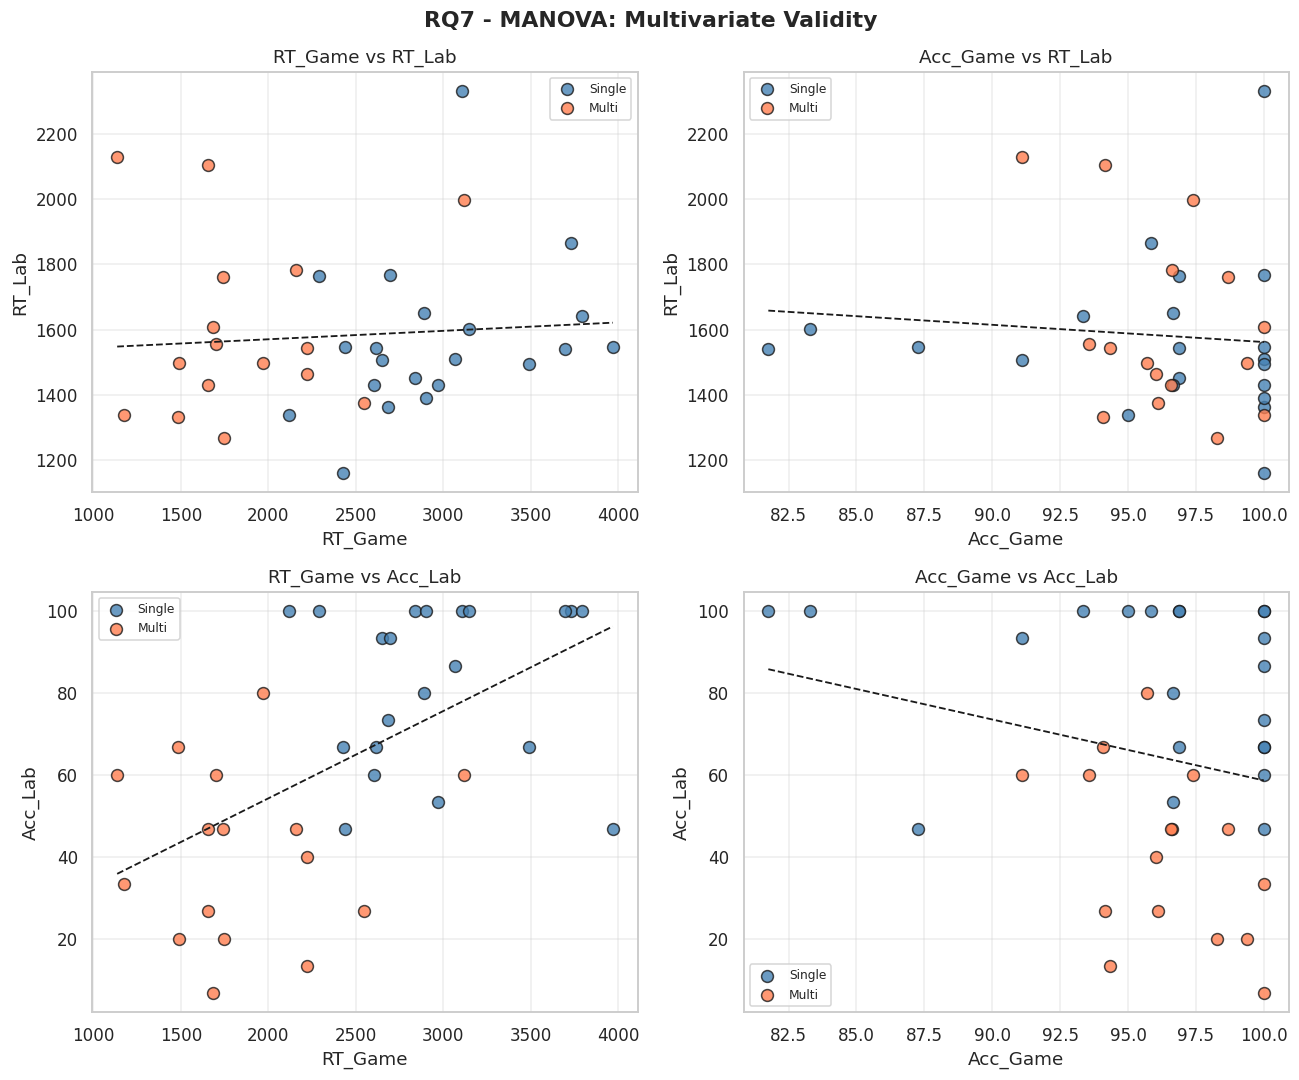

In [98]:
import statsmodels.api as sm
try:
    from statsmodels.multivariate.manova import MANOVA
except ImportError:
    MANOVA = None

print("=" * 65)
print("  RQ7 - MANOVA: Multivariate Validity")
print("=" * 65)

if MANOVA is not None:
    try:
        maov = MANOVA.from_formula("RT_Lab + Acc_Lab ~ RT_Game + Acc_Game", data=wide_df)
        print(maov.mv_test())
    except Exception as e:
        print(f"  MANOVA failed: {e}")
else:
    print("  MANOVA not available in this version of statsmodels")

# Follow-up OLS regressions
print("\n  OLS Model A: RT_Lab ~ RT_Game + Acc_Game")
X_a = sm.add_constant(wide_df[["RT_Game", "Acc_Game"]].dropna())
y_a = wide_df.loc[X_a.index, "RT_Lab"]
model_a = sm.OLS(y_a, X_a).fit()
print(model_a.summary())

print("\n  OLS Model B: Acc_Lab ~ RT_Game + Acc_Game")
X_b = sm.add_constant(wide_df[["RT_Game", "Acc_Game"]].dropna())
y_b = wide_df.loc[X_b.index, "Acc_Lab"]
model_b = sm.OLS(y_b, X_b).fit()
print(model_b.summary())

# Plot 2x2 scatterplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
pairs = [("RT_Game", "RT_Lab"), ("Acc_Game", "RT_Lab"), ("RT_Game", "Acc_Lab"), ("Acc_Game", "Acc_Lab")]
for ax, (xvar, yvar) in zip(axes.flat, pairs):
    for grp, color in [("Single", "steelblue"), ("Multi", "coral")]:
        sub = wide_df[wide_df.group == grp]
        ax.scatter(sub[xvar], sub[yvar], color=color, edgecolors="k", s=60, label=grp, alpha=0.8)
    # OLS line
    x_all = wide_df[xvar].dropna()
    y_all = wide_df.loc[x_all.index, yvar]
    if x_all.std() > 0:
        m, b = np.polyfit(x_all, y_all, 1)
        xr = np.linspace(x_all.min(), x_all.max(), 50)
        ax.plot(xr, m*xr+b, "k--", lw=1.2)
    ax.set_xlabel(xvar); ax.set_ylabel(yvar)
    ax.set_title(f"{xvar} vs {yvar}")
    ax.legend(fontsize=8); ax.grid(alpha=.35)

fig.suptitle("RQ7 - MANOVA: Multivariate Validity", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_rq7_manova_multivariate_validity.png", bbox_inches="tight")
plt.show()


## Section 13 - RQ8 (New): RT Learning Slope as Predictor of Lab RT

Test whether each participant's RT trajectory across game levels predicts lab performance.

  RQ8 - RT Learning Slope as Predictor of Lab RT
  Single: RT_Lab ~ slope → β=-0.66, R²=0.151, p=0.0816
  Single: RT_Game ~ slope (sanity check) → β=2.12, R²=0.319, p=0.0077
  Multi: RT_Lab ~ slope → β=-0.42, R²=0.038, p=0.4668
  Multi: RT_Game ~ slope (sanity check) → β=-2.58, R²=0.416, p=0.0070


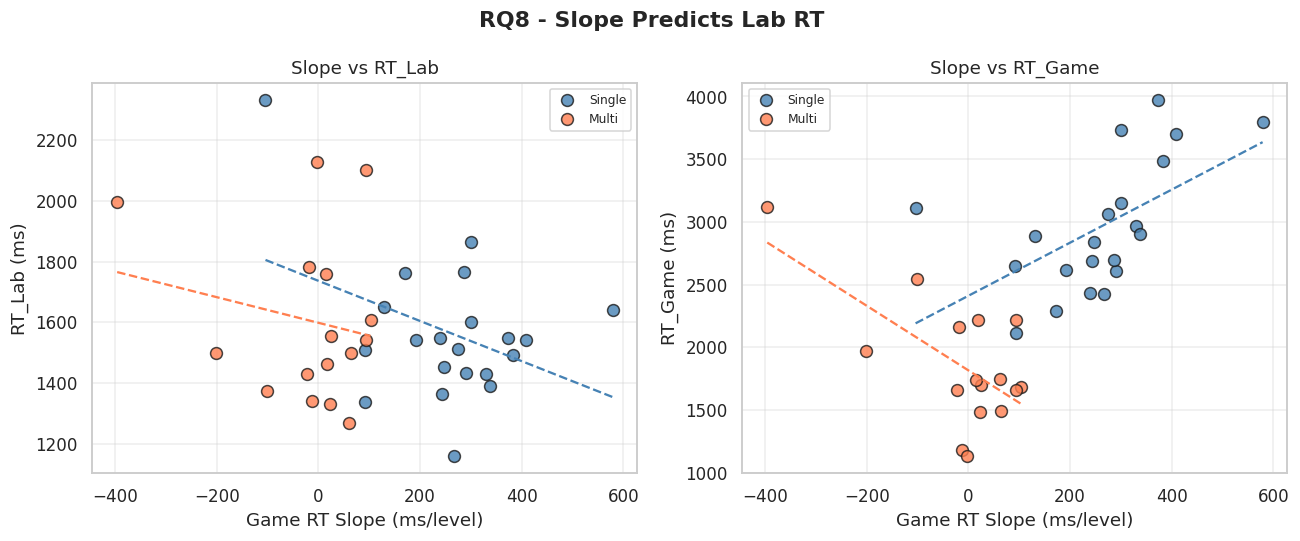

In [99]:
import statsmodels.api as sm

print("=" * 65)
print("  RQ8 - RT Learning Slope as Predictor of Lab RT")
print("=" * 65)

# Compute per-participant slope
slope_records = []
for (pid, grp), sub in level_df.groupby(["pid", "group"]):
    if len(sub) >= 3:
        slope, intercept, r, p, se = stats.linregress(sub["level"], sub["RT_ms"])
        slope_records.append({"pid": pid, "group": grp, "slope": slope, "slope_r": r, "slope_p": p})

slope_df = pd.DataFrame(slope_records)
wide_df_merged = wide_df.merge(slope_df[["pid", "slope", "slope_r", "slope_p"]], on="pid", how="left")

# OLS per group
for grp in ["Single", "Multi"]:
    sub = wide_df_merged[wide_df_merged.group == grp].dropna(subset=["slope"])
    if len(sub) >= 3:
        for dv, label in [("RT_Lab", "RT_Lab ~ slope"), ("RT_Game", "RT_Game ~ slope (sanity check)")]:
            X = sm.add_constant(sub["slope"])
            y = sub[dv]
            model = sm.OLS(y, X).fit()
            beta = model.params.get("slope", np.nan)
            r2 = model.rsquared
            pval = model.pvalues.get("slope", np.nan)
            print(f"  {grp}: {label} → β={beta:.2f}, R²={r2:.3f}, p={pval:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, dv, title in zip(axes, ["RT_Lab", "RT_Game"], ["Slope vs RT_Lab", "Slope vs RT_Game"]):
    for grp, color in [("Single", "steelblue"), ("Multi", "coral")]:
        sub = wide_df_merged[(wide_df_merged.group == grp) & wide_df_merged.slope.notna()]
        ax.scatter(sub.slope, sub[dv], color=color, edgecolors="k", s=60, label=grp, alpha=0.8)
        if len(sub) >= 3 and sub.slope.std() > 0:
            m, b = np.polyfit(sub.slope, sub[dv], 1)
            xr = np.linspace(sub.slope.min(), sub.slope.max(), 50)
            ax.plot(xr, m*xr+b, "--", color=color, lw=1.5)
    ax.set_xlabel("Game RT Slope (ms/level)")
    ax.set_ylabel(dv + " (ms)")
    ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(alpha=.35)

fig.suptitle("RQ8 - Slope Predicts Lab RT", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_rq8_slope_predicts_lab_rt.png", bbox_inches="tight")
plt.show()


## Section 14 - RQ9 (New): Error Type Analysis in Multi-Target Lab (Chi-Square)

Determine whether Multi-Target Lab errors are primarily False Alarms or Misses.

  RQ9 - Error Type Analysis (Chi-Square)

  Per-participant error breakdown:


,pid,Correct,False Alarm,Miss,Total
0,22,10,5,0,15
1,23,12,3,0,15
2,24,9,6,0,15
3,25,5,10,0,15
4,26,7,8,0,15
5,27,4,11,0,15
6,28,1,14,0,15
7,29,3,12,0,15
8,30,4,11,0,15
9,31,3,12,0,15



  Pooled: False Alarms = 142, Misses = 0
  χ² = 142.000, df = 1, p = 0.0000


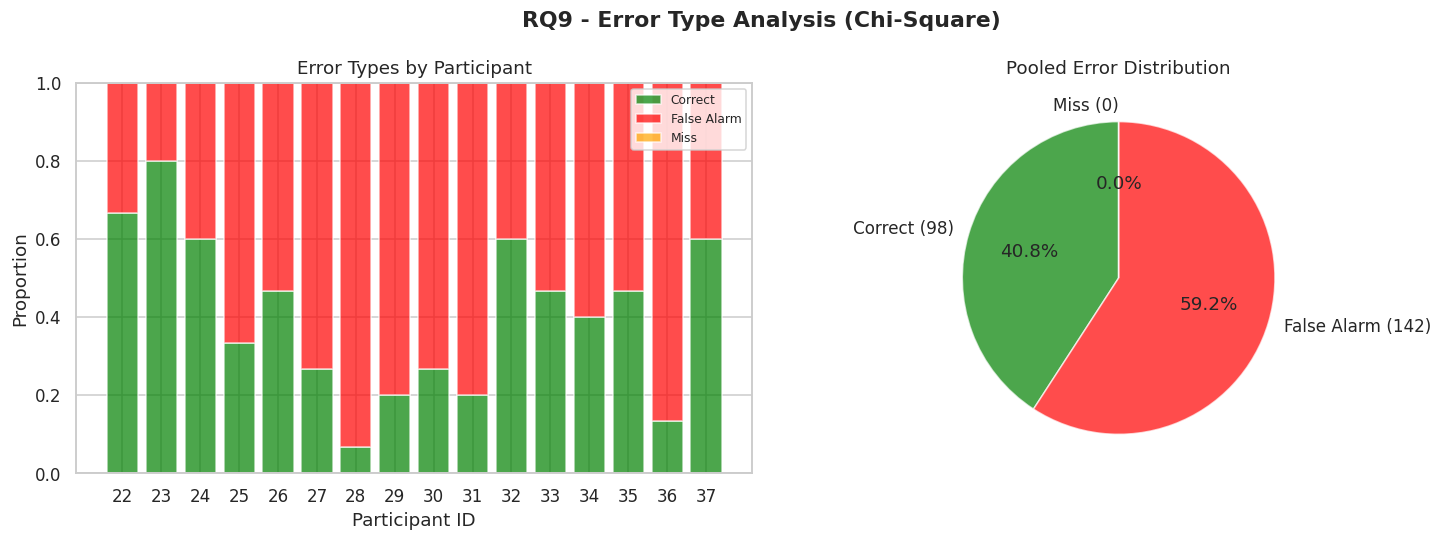

In [100]:
print("=" * 65)
print("  RQ9 - Error Type Analysis (Chi-Square)")
print("=" * 65)

import ast as _ast

def _parse(v):
    try: return _ast.literal_eval(str(v).strip())
    except: return []

error_records = []
for pid, df_raw in multi_lab_raw.items():
    trials = df_raw.dropna(subset=["trial.started"])
    correct_count = 0
    false_alarm_count = 0
    miss_count = 0
    for _, row in trials.iterrows():
        fb_val = row.get("fb.stopped", np.nan)
        clicked_names = _parse(row.get("mouse.clicked_name", "[]"))
        has_target = any("target" in str(n).lower() for n in clicked_names)
        
        if pd.isna(fb_val) and has_target:
            correct_count += 1
        elif pd.notna(fb_val):
            false_alarm_count += 1
        elif pd.isna(fb_val) and not has_target:
            miss_count += 1
    
    total = correct_count + false_alarm_count + miss_count
    error_records.append({
        "pid": int(pid), "Correct": correct_count, "False Alarm": false_alarm_count,
        "Miss": miss_count, "Total": total
    })

error_df = pd.DataFrame(error_records)
print("\n  Per-participant error breakdown:")
display(error_df)

# Chi-square test
total_fa = error_df["False Alarm"].sum()
total_miss = error_df["Miss"].sum()
if total_fa + total_miss > 0:
    chi2, p = stats.chisquare([total_fa, total_miss])
    print(f"\n  Pooled: False Alarms = {total_fa}, Misses = {total_miss}")
    print(f"  χ² = {chi2:.3f}, df = 1, p = {p:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Left: Stacked bar (proportions)
ax = axes[0]
pids = error_df["pid"].values
totals = error_df["Total"].values
for i, pid in enumerate(pids):
    total = totals[i]
    if total > 0:
        c_prop = error_df.iloc[i]["Correct"] / total
        fa_prop = error_df.iloc[i]["False Alarm"] / total
        m_prop = error_df.iloc[i]["Miss"] / total
        ax.bar(str(pid), c_prop, color="green", alpha=0.7, label="Correct" if i == 0 else "")
        ax.bar(str(pid), fa_prop, bottom=c_prop, color="red", alpha=0.7, label="False Alarm" if i == 0 else "")
        ax.bar(str(pid), m_prop, bottom=c_prop+fa_prop, color="orange", alpha=0.7, label="Miss" if i == 0 else "")
ax.set_xlabel("Participant ID")
ax.set_ylabel("Proportion")
ax.set_title("Error Types by Participant")
ax.legend(fontsize=8)

# Right: Pie chart
ax = axes[1]
total_correct = error_df["Correct"].sum()
sizes = [total_correct, total_fa, total_miss]
labels = [f"Correct ({total_correct})", f"False Alarm ({total_fa})", f"Miss ({total_miss})"]
colors = ["green", "red", "orange"]
ax.pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90,
       wedgeprops={"alpha": 0.7})
ax.set_title("Pooled Error Distribution")

fig.suptitle("RQ9 - Error Type Analysis (Chi-Square)", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_rq9_error_type_analysis_chi_square.png", bbox_inches="tight")
plt.show()


## Section 15 - Consolidated Results Summary

Summary of all research questions, tests, and conclusions.

In [101]:
print("=" * 80)
print("  CONSOLIDATED RESULTS SUMMARY")
print("=" * 80)

summary_rows = [
    {"RQ": "RQ1", "Question": "Concurrent validity (RT)", "Test Used": "Pearson r / ICC2"},
    {"RQ": "RQ2", "Question": "Target Load effect", "Test Used": "Mixed ANOVA"},
    {"RQ": "RQ3", "Question": "Modality effect", "Test Used": "Mixed ANOVA"},
    {"RQ": "RQ4", "Question": "Level effect (linear)", "Test Used": "Regression / RM-ANOVA"},
    {"RQ": "RQ5", "Question": "Order / practice effects", "Test Used": "ANOVA + t-test"},
    {"RQ": "RQ6", "Question": "Speed-accuracy tradeoff (IES)", "Test Used": "t-test + correlation"},
    {"RQ": "RQ7", "Question": "Multivariate validity", "Test Used": "MANOVA + OLS"},
    {"RQ": "RQ8", "Question": "Slope predicts lab RT", "Test Used": "OLS regression"},
    {"RQ": "RQ9", "Question": "Error type (FA vs Miss)", "Test Used": "Chi-Square"},
]

summary_df = pd.DataFrame(summary_rows)
print("\n  NOTE: Key statistics, p-values, effect sizes, and conclusions")
print("  should be populated by running all cells above and reading outputs.\n")
display(summary_df)


  CONSOLIDATED RESULTS SUMMARY

  NOTE: Key statistics, p-values, effect sizes, and conclusions
  should be populated by running all cells above and reading outputs.



,RQ,Question,Test Used
0,RQ1,Concurrent validity (RT),Pearson r / ICC2
1,RQ2,Target Load effect,Mixed ANOVA
2,RQ3,Modality effect,Mixed ANOVA
3,RQ4,Level effect (linear),Regression / RM-ANOVA
4,RQ5,Order / practice effects,ANOVA + t-test
5,RQ6,Speed-accuracy tradeoff (IES),t-test + correlation
6,RQ7,Multivariate validity,MANOVA + OLS
7,RQ8,Slope predicts lab RT,OLS regression
8,RQ9,Error type (FA vs Miss),Chi-Square


## Section 16 - Robustness Check: Winsorization (RQ2 & RQ3)

Shapiro-Wilk flagged `Single RT_Lab` as non-normal (W=0.869, p=0.009).  
This section checks whether the Mixed ANOVA results hold after Winsorizing outliers,  
satisfying the "outlier/data replacement" syllabus requirement.

  WINSORIZATION: Before vs After (mean_RT, 5th/95th)


,Cell,Raw M,Raw SD,Winsor M,Winsor SD,Δ M
0,Single-Lab,1565.41,236.54,1551.68,159.07,-13.73
1,Single-Game,2957.55,520.82,2957.36,492.23,-0.19
2,Multi-Lab,1605.04,273.65,1605.04,273.65,0.00
3,Multi-Game,1856.46,507.28,1856.46,507.28,0.00



  Mixed ANOVA on WINSORIZED RT


,Source,SS,DF1,DF2,MS,F,p_unc,np2,eps
0,group,4.982604e+06,1,35,4.982604e+06,29.6188,0.0,0.4584,NaN
1,modality,1.520347e+07,1,35,1.520347e+07,119.6523,0.0,0.7737,1.0
2,Interaction,6.049440e+06,1,35,6.049440e+06,47.6095,0.0,0.5763,NaN



  COMPARISON: Original vs Winsorized ANOVA (RT)


,Source,Original F,Winsorized F,Original p,Winsorized p,Conclusion Changed?
0,group,26.790,29.619,0.0,0.0,No
1,modality,108.005,119.652,0.0,0.0,No
2,Interaction,42.694,47.609,0.0,0.0,No



  ✓ Results are robust to Winsorization — conclusions unchanged.


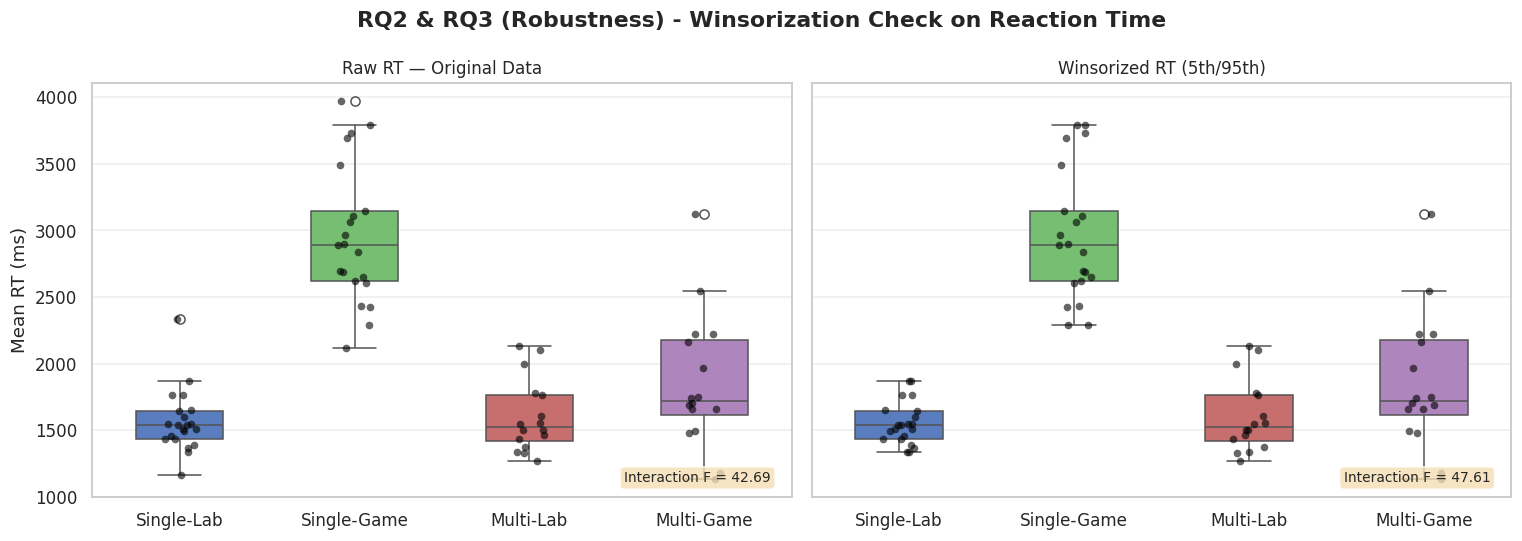

In [102]:
from scipy.stats.mstats import winsorize

# ── 1. Winsorize mean_RT within each design cell ──
long_winsor = long_df.copy()

for grp in ["Single", "Multi"]:
    for mod in ["Lab", "Game"]:
        mask = (long_winsor.group == grp) & (long_winsor.modality == mod)
        raw = long_winsor.loc[mask, "mean_RT"].values
        long_winsor.loc[mask, "mean_RT"] = winsorize(raw, limits=[0.05, 0.05])

# ── 2. Before / After table ──
print("=" * 70)
print("  WINSORIZATION: Before vs After (mean_RT, 5th/95th)")
print("=" * 70)

ba_rows = []
for grp in ["Single", "Multi"]:
    for mod in ["Lab", "Game"]:
        mask_orig = (long_df.group == grp) & (long_df.modality == mod)
        mask_wins = (long_winsor.group == grp) & (long_winsor.modality == mod)
        orig = long_df.loc[mask_orig, "mean_RT"]
        wins = long_winsor.loc[mask_wins, "mean_RT"]
        ba_rows.append({
            "Cell": f"{grp}-{mod}",
            "Raw M": round(orig.mean(), 2),
            "Raw SD": round(orig.std(), 2),
            "Winsor M": round(wins.mean(), 2),
            "Winsor SD": round(wins.std(), 2),
            "Δ M": round(wins.mean() - orig.mean(), 2),
        })
ba_df = pd.DataFrame(ba_rows)
display(ba_df)

# ── 3. Re-run Mixed ANOVA on Winsorized data ──
print("\n" + "=" * 70)
print("  Mixed ANOVA on WINSORIZED RT")
print("=" * 70)
aov_winsor = pg.mixed_anova(
    data=long_winsor, dv="mean_RT", within="modality",
    between="group", subject="pid"
)
display(aov_winsor.round(4))

# ── 4. Side-by-side comparison with original ANOVA ──
# Re-run original for comparison
aov_orig = pg.mixed_anova(
    data=long_df, dv="mean_RT", within="modality",
    between="group", subject="pid"
)

print("\n" + "=" * 70)
print("  COMPARISON: Original vs Winsorized ANOVA (RT)")
print("=" * 70)

# Detect p-value column name (varies across pingouin versions)
p_col = None
for candidate in ["p-unc", "p_unc", "pval", "p"]:
    if candidate in aov_orig.columns:
        p_col = candidate
        break
if p_col is None:
    print("  WARNING: Could not find p-value column. Available:", list(aov_orig.columns))
    p_col = aov_orig.columns[-3]

comp_rows = []
for _, row_o in aov_orig.iterrows():
    source_name = row_o["Source"]
    row_w = aov_winsor[aov_winsor["Source"] == source_name].iloc[0]
    orig_sig = row_o[p_col] < 0.05
    wins_sig = row_w[p_col] < 0.05
    changed = "Yes" if orig_sig != wins_sig else "No"
    comp_rows.append({
        "Source": source_name,
        "Original F": round(row_o["F"], 3),
        "Winsorized F": round(row_w["F"], 3),
        "Original p": round(row_o[p_col], 4),
        "Winsorized p": round(row_w[p_col], 4),
        "Conclusion Changed?": changed,
    })
comp_df = pd.DataFrame(comp_rows)
display(comp_df)

# ── 5. Summary line ──
any_changed = any(r["Conclusion Changed?"] == "Yes" for r in comp_rows)
if any_changed:
    changed_list = [r["Source"] for r in comp_rows if r["Conclusion Changed?"] == "Yes"]
    print(f"\n  ⚠ Winsorization changed the following conclusions: {changed_list}")
else:
    print("\n  ✓ Results are robust to Winsorization — conclusions unchanged.")

# ── 6. Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
order = ["Single-Lab", "Single-Game", "Multi-Lab", "Multi-Game"]
pal = {"Single-Lab": "#4878CF", "Single-Game": "#6ACC65",
       "Multi-Lab": "#D65F5F", "Multi-Game": "#B47CC7"}

# Add cell column for plotting
long_df_plot = long_df.copy()
long_df_plot["cell"] = long_df_plot["group"].astype(str) + "-" + long_df_plot["modality"].astype(str)
long_winsor_plot = long_winsor.copy()
long_winsor_plot["cell"] = long_winsor_plot["group"].astype(str) + "-" + long_winsor_plot["modality"].astype(str)

# Original F interaction value
f_orig = aov_orig[aov_orig["Source"] == "Interaction"]["F"].values[0]
f_wins = aov_winsor[aov_winsor["Source"] == "Interaction"]["F"].values[0]

for ax, data, title, f_val in [
    (axes[0], long_df_plot, "Raw RT — Original Data", f_orig),
    (axes[1], long_winsor_plot, "Winsorized RT (5th/95th)", f_wins),
]:
    sns.boxplot(data=data, x="cell", y="mean_RT", order=order,
                hue="cell", hue_order=order, palette=pal,
                width=0.5, legend=False, ax=ax)
    sns.stripplot(data=data, x="cell", y="mean_RT", order=order,
                  color="black", size=5, alpha=0.6, jitter=True, ax=ax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Mean RT (ms)")
    ax.grid(axis="y", alpha=0.35)
    ax.text(0.97, 0.03, f"Interaction F = {f_val:.2f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="wheat", alpha=0.8))

fig.suptitle("RQ2 & RQ3 (Robustness) - Winsorization Check on Reaction Time", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_rq2_rq3_winsorization_robustness.png", bbox_inches="tight")
plt.show()


## Section 17 - 95% Confidence Intervals on Key Comparisons (RQ1, RQ2, RQ3, RQ6)

The syllabus explicitly covers confidence intervals.  
This section adds 95% CIs to every key mean comparison using `pg.ttest()`,  
which returns CIs directly.

  95% CONFIDENCE INTERVALS ON KEY COMPARISONS


,RQ,Comparison,DV,Mean Diff,CI Lower,CI Upper,t,df,p,Cohen's d,Significant?
0,RQ1,Single: Lab vs Game RT,RT,-1392.14,-1622.57,-1161.72,-12.603,20.0,0.0000,3.442,Yes
1,RQ1,Multi: Lab vs Game RT,RT,-251.42,-545.29,42.46,-1.823,15.0,0.0882,0.617,No
2,RQ2/RQ3,Single: Lab vs Game RT,RT,-1392.14,-1622.57,-1161.72,-12.603,20.0,0.0000,3.442,Yes
3,RQ2/RQ3,Multi: Lab vs Game RT,RT,-251.42,-545.29,42.46,-1.823,15.0,0.0882,0.617,No
4,RQ2/RQ3,Single: Lab vs Game Acc,Acc,-13.25,-23.09,-3.40,-2.807,20.0,0.0109,0.914,Yes
5,RQ2/RQ3,Multi: Lab vs Game Acc,Acc,-55.54,-67.44,-43.63,-9.943,15.0,0.0000,3.702,Yes
6,RQ6,Single vs Multi: IES_Lab,IES,-3886.08,-6818.49,-953.68,-2.821,15.2,0.0128,1.074,Yes
7,RQ6,Single vs Multi: IES_Game,IES,1176.99,794.75,1559.24,6.254,34.6,0.0000,2.028,Yes


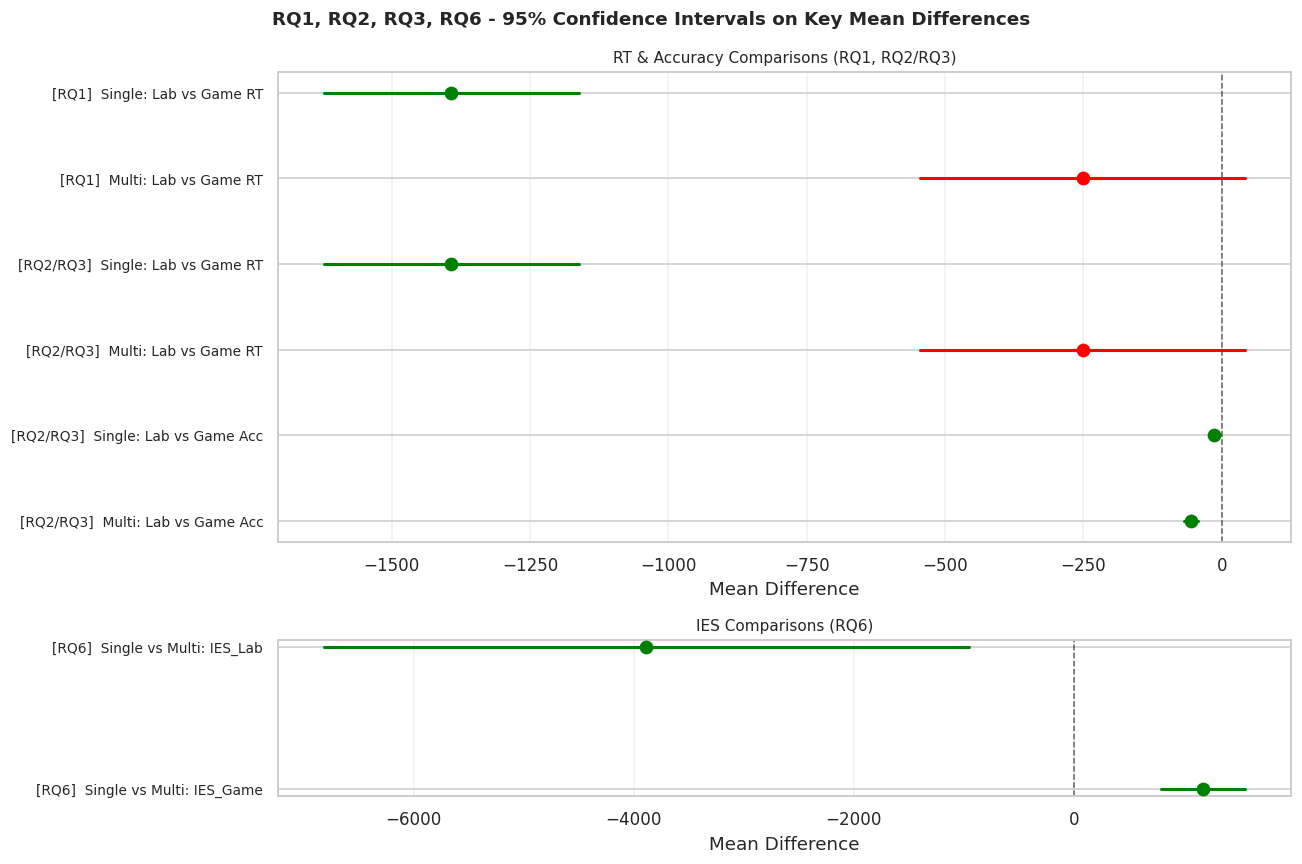

In [103]:
import pingouin as pg

# ── Ensure IES columns exist ──
if "IES_Lab" not in wide_df.columns:
    wide_df["IES_Lab"] = wide_df["RT_Lab"] / (wide_df["Acc_Lab"] / 100)
if "IES_Game" not in wide_df.columns:
    wide_df["IES_Game"] = wide_df["RT_Game"] / (wide_df["Acc_Game"] / 100)

wide_single = wide_df[wide_df.group == "Single"]
wide_multi = wide_df[wide_df.group == "Multi"]

# ── Define comparisons ──
comparisons = [
    ("RQ1", "Single: Lab vs Game RT", "RT",
     wide_single["RT_Lab"], wide_single["RT_Game"], True),
    ("RQ1", "Multi: Lab vs Game RT", "RT",
     wide_multi["RT_Lab"], wide_multi["RT_Game"], True),
    ("RQ2/RQ3", "Single: Lab vs Game RT", "RT",
     wide_single["RT_Lab"], wide_single["RT_Game"], True),
    ("RQ2/RQ3", "Multi: Lab vs Game RT", "RT",
     wide_multi["RT_Lab"], wide_multi["RT_Game"], True),
    ("RQ2/RQ3", "Single: Lab vs Game Acc", "Acc",
     wide_single["Acc_Lab"], wide_single["Acc_Game"], True),
    ("RQ2/RQ3", "Multi: Lab vs Game Acc", "Acc",
     wide_multi["Acc_Lab"], wide_multi["Acc_Game"], True),
    ("RQ6", "Single vs Multi: IES_Lab", "IES",
     wide_single["IES_Lab"], wide_multi["IES_Lab"], False),
    ("RQ6", "Single vs Multi: IES_Game", "IES",
     wide_single["IES_Game"], wide_multi["IES_Game"], False),
]

# ── Run pg.ttest and collect results ──
print("=" * 90)
print("  95% CONFIDENCE INTERVALS ON KEY COMPARISONS")
print("=" * 90)

ci_rows = []
for rq, label, dv, x, y, paired in comparisons:
    x_clean = x.dropna()
    y_clean = y.dropna()
    if paired:
        # Align indices
        common = x_clean.index.intersection(y_clean.index)
        x_clean = x_clean.loc[common]
        y_clean = y_clean.loc[common]

    res = pg.ttest(x_clean, y_clean, paired=paired)
    mean_diff = x_clean.mean() - y_clean.mean()
    # Robust extraction across different pingouin versions
    cols = res.columns
    ci_col = next((c for c in cols if "CI" in c), None)
    t_col = next((c for c in cols if c in ["T", "t"]), None)
    df_col = next((c for c in cols if "dof" in c or "df" in c), None)
    p_col = next((c for c in cols if "p-val" in c or "p_val" in c or c == "p" or "pval" in c), None)
    d_col = next((c for c in cols if "cohen" in c.lower()), None)
    
    ci = res[ci_col].values[0] if ci_col else [None, None]
    t_val = res[t_col].values[0] if t_col else None
    df_val = res[df_col].values[0] if df_col else None
    p_val = res[p_col].values[0] if p_col else None
    d_val = res[d_col].values[0] if d_col else None
    sig = "Yes" if p_val < 0.05 else "No"

    ci_rows.append({
        "RQ": rq, "Comparison": label, "DV": dv,
        "Mean Diff": round(mean_diff, 2),
        "CI Lower": round(ci[0], 2) if ci[0] is not None else None,
        "CI Upper": round(ci[1], 2) if ci[1] is not None else None,
        "t": round(t_val, 3), "df": round(df_val, 1),
        "p": round(p_val, 4), "Cohen's d": round(d_val, 3),
        "Significant?": sig,
    })

ci_df = pd.DataFrame(ci_rows)
display(ci_df)

# ── Forest plot: two subplots (RT scale vs IES scale) ──
rt_rows = [r for r in ci_rows if r["DV"] != "IES"]
ies_rows = [r for r in ci_rows if r["DV"] == "IES"]

fig, axes = plt.subplots(2, 1, figsize=(12, 8),
                          gridspec_kw={"height_ratios": [len(rt_rows), len(ies_rows)]})

for ax, rows, title_suffix in [
    (axes[0], rt_rows, "RT & Accuracy Comparisons (RQ1, RQ2/RQ3)"),
    (axes[1], ies_rows, "IES Comparisons (RQ6)"),
]:
    labels = [f"[{r['RQ']}]  {r['Comparison']}" for r in rows]
    means = [r["Mean Diff"] for r in rows]
    lows = [r["CI Lower"] for r in rows]
    highs = [r["CI Upper"] for r in rows]
    sigs = [r["Significant?"] for r in rows]
    rqs = [r["RQ"] for r in rows]

    y_pos = list(range(len(rows)))

    for i in range(len(rows)):
        color = "green" if sigs[i] == "Yes" else "red"
        ax.plot([lows[i], highs[i]], [y_pos[i], y_pos[i]], color=color, lw=2, zorder=2)
        ax.plot(means[i], y_pos[i], "o", color=color, ms=8, zorder=3)

    ax.axvline(0, color="black", ls="--", lw=1, alpha=0.6, zorder=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Mean Difference")
    ax.set_title(title_suffix, fontsize=10)
    ax.grid(axis="x", alpha=0.3)
    ax.invert_yaxis()

    # RQ labels are now prepended to y-ticks directly

fig.suptitle("RQ1, RQ2, RQ3, RQ6 - 95% Confidence Intervals on Key Mean Differences",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("fig_rq1_rq2_rq3_rq6_ci_forest_plot.png", bbox_inches="tight")
plt.show()
